1. Customer information
- gender — Male/Female
- SeniorCitizen — 0/1
- Partner — Yes/No
- Dependents — Yes/No
2. Account information
- tenure — Number of months the customer has stayed
- Contract — Month-to-month / One year / Two year
- PaperlessBilling — Yes/No
- PaymentMethod — Electronic check, bank transfer, credit card, etc.
3. Phone services
- PhoneService — Yes/No
- MultipleLines — Yes/No/No phone service
4. Internet services
- InternetService — DSL / Fiber optic / No
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
These generally contain categories such as Yes, No, or No internet service.
5. Numerical financial features
- MonthlyCharges — Monthly amount charged
- TotalCharges — Total amount charged over the customer's tenure
6. Target
- Churn — whether the customer left the service:
  - Yes → churned
  - No → retained

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("IT_customer_churn.csv")

In [4]:
object_columns = df.select_dtypes(include=['object', 'bool']).columns
print("Object type columns:")
print(object_columns)

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("\nNumerical type columns:")
print(numerical_columns)

Object type columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='str')

Numerical type columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')


In [9]:
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
def classify_features(df):
    categorical_features = []
    non_categorical_features = []
    discrete_features = []
    continuous_features = []

    for column in df.columns:
        if df[column].dtype in ['str']:
            if df[column].nunique() < 10:
                categorical_features.append(column)
            else:
                non_categorical_features.append(column)
        elif df[column].dtype in ['int64', 'float64']:
            if df[column].nunique() < 10:
                discrete_features.append(column)
            else:
                continuous_features.append(column)

    return categorical_features, non_categorical_features, discrete_features, continuous_features

In [8]:
categorical, non_categorical, discrete, continuous = classify_features(df)
print("Categorical Features:", categorical)
print("Non-Categorical Features:", non_categorical)
print("Discrete Features:", discrete)
print("Continuous Features:", continuous)

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Non-Categorical Features: ['TotalCharges']
Discrete Features: ['SeniorCitizen']
Continuous Features: ['tenure', 'MonthlyCharges']


In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Shape: ", df.shape)
print("\nData Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nDescriptive Statistics:\n")
for col in categorical:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))

print("\nNumerical Summary:\n")
print(df[non_categorical + discrete + continuous].describe().T)

Shape:  (7043, 20)

Data Types:

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing Values:

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
Payment

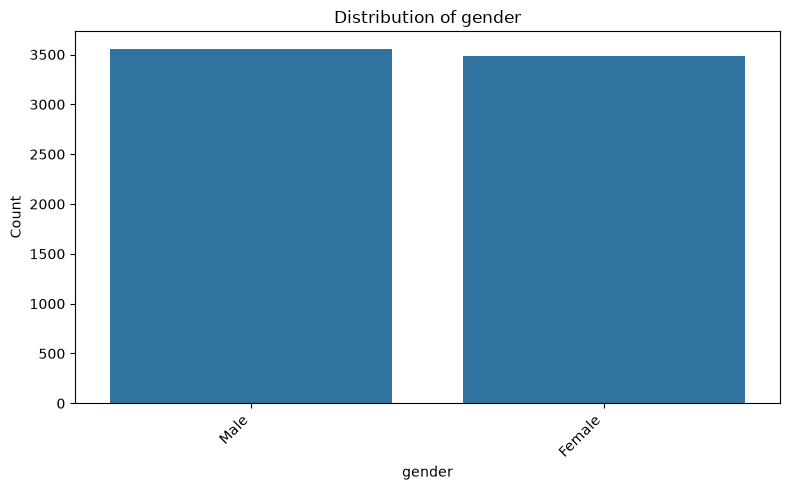

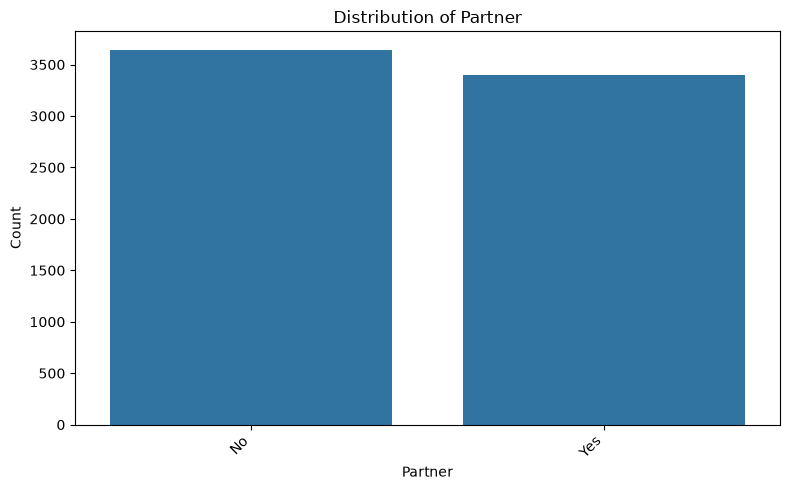

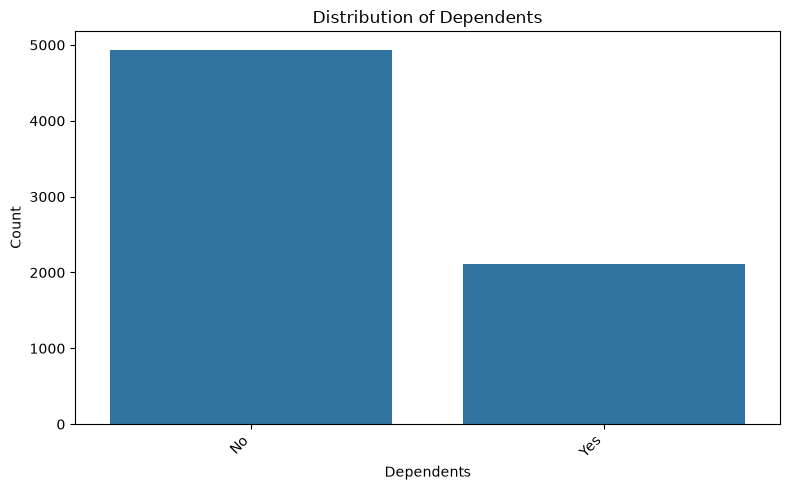

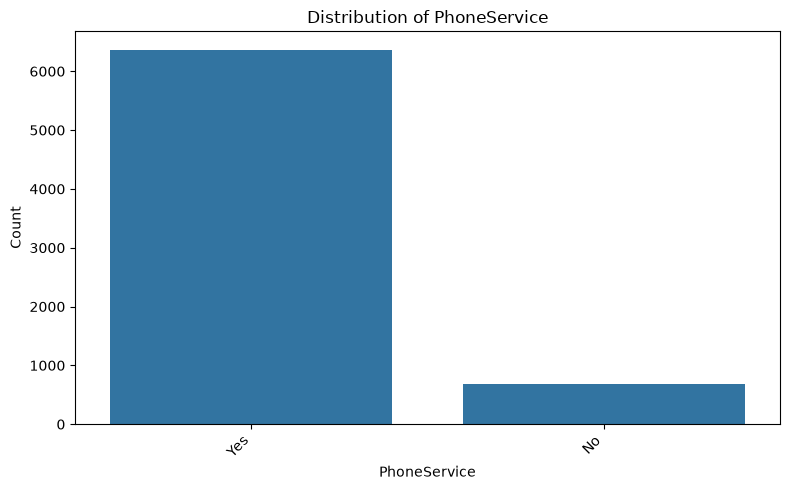

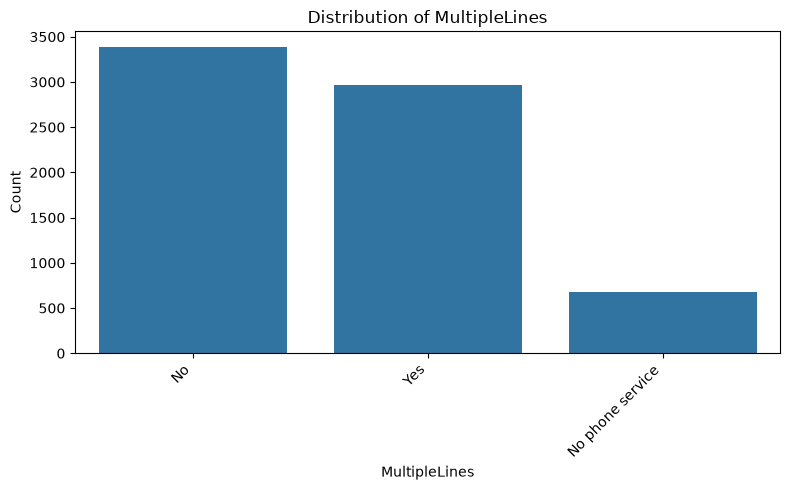

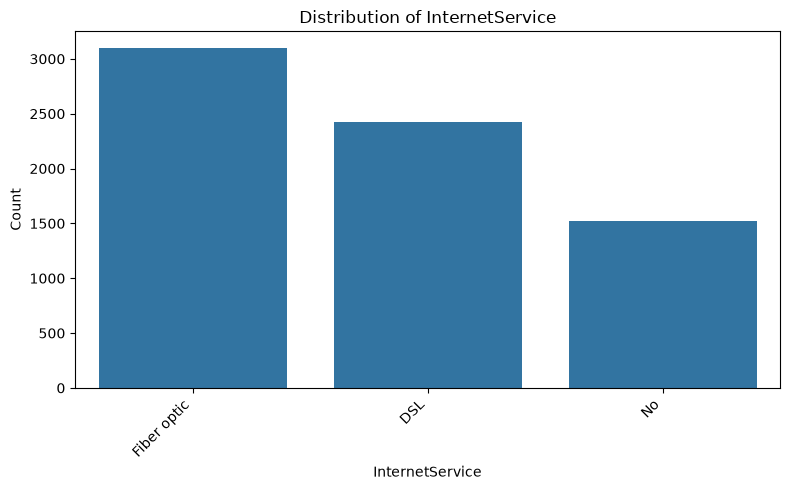

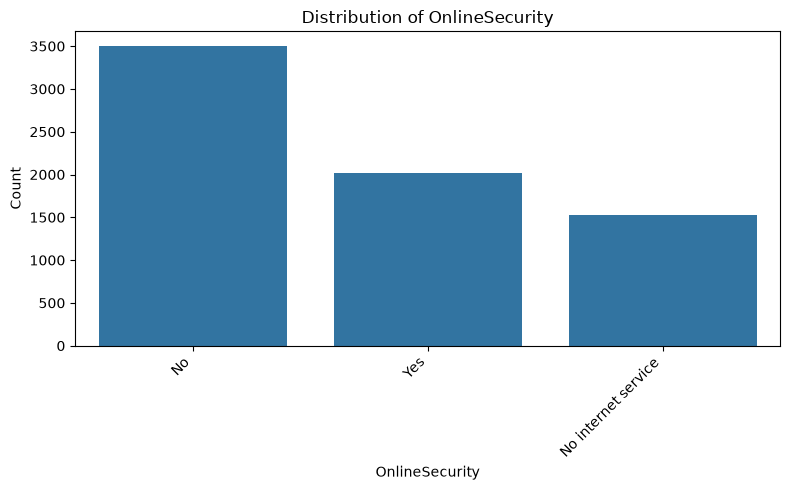

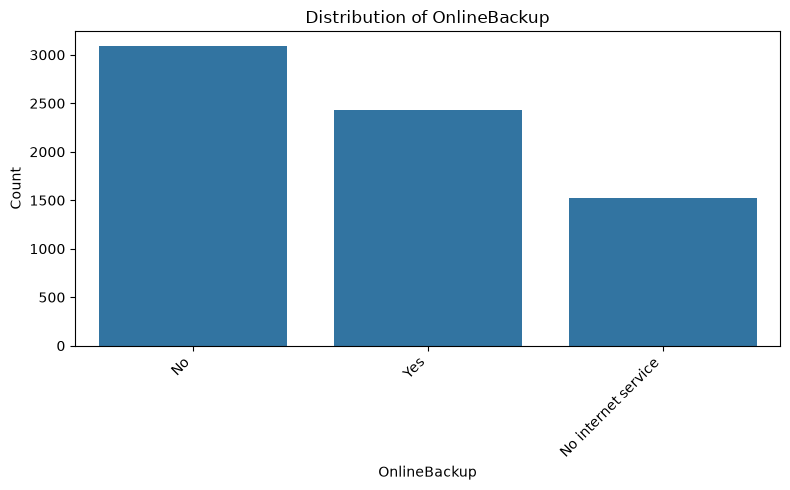

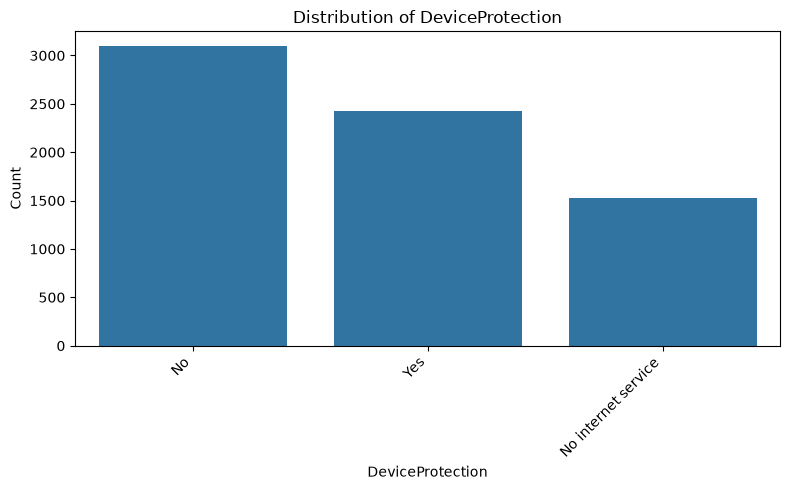

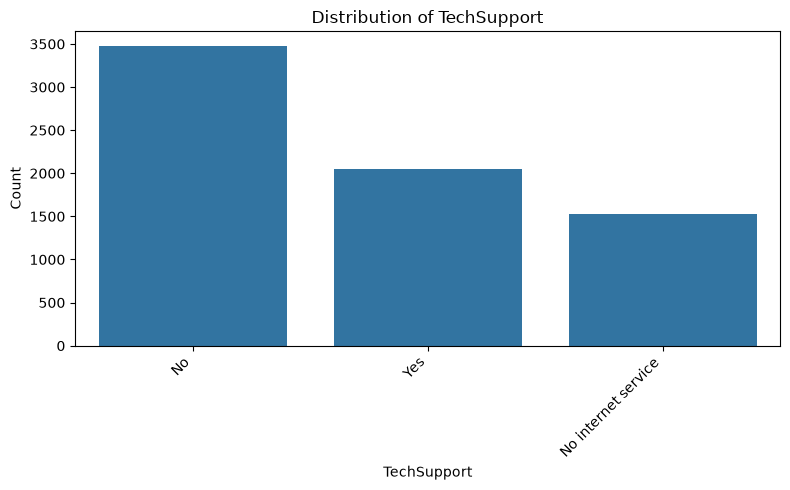

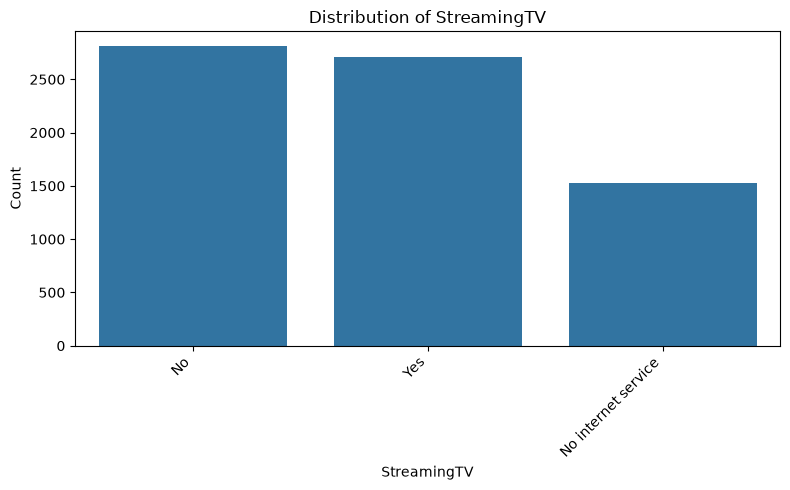

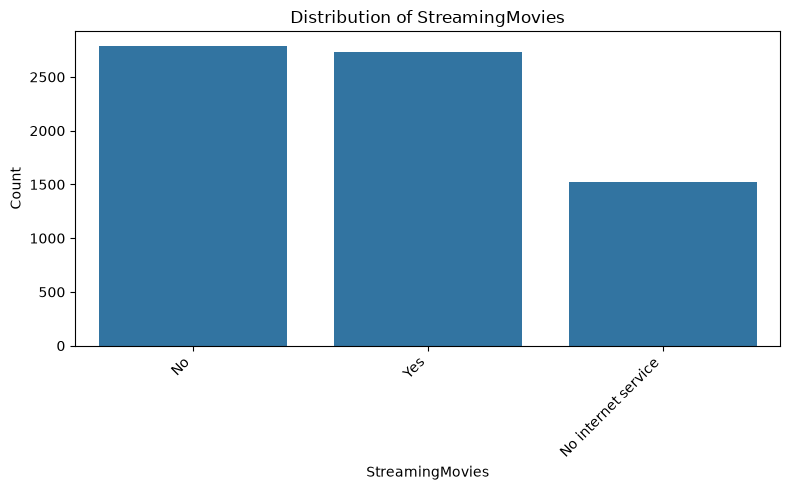

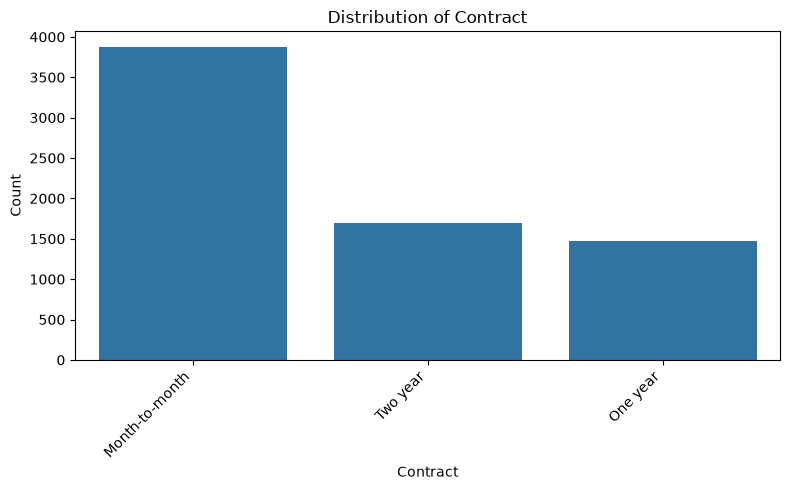

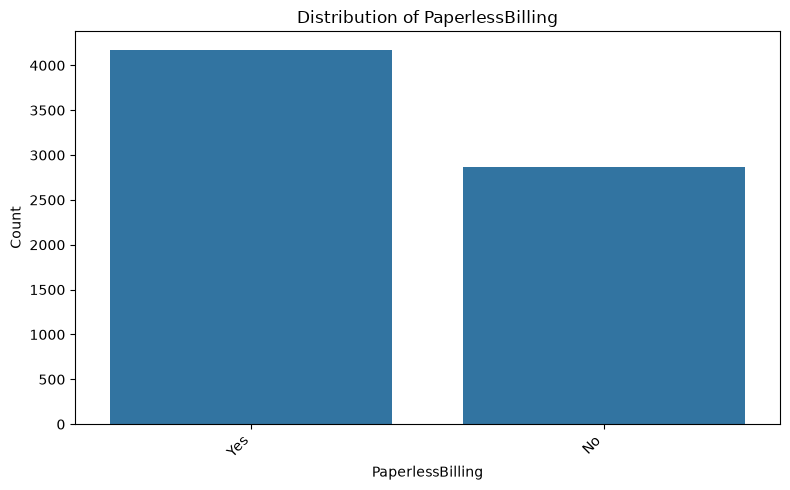

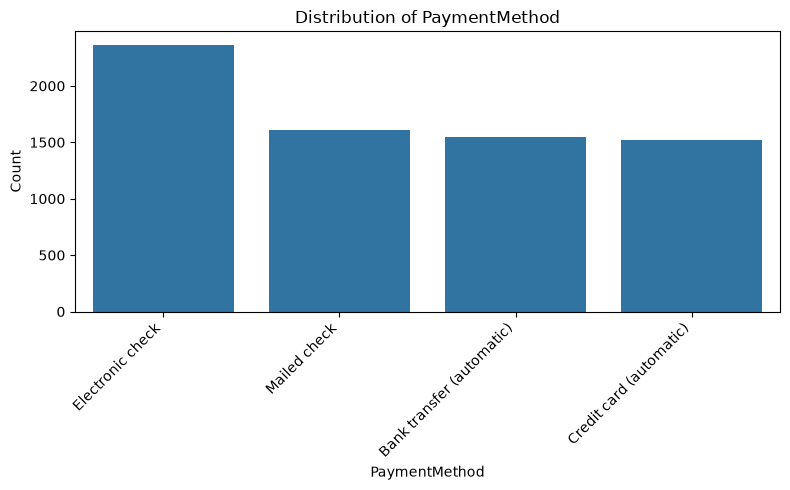

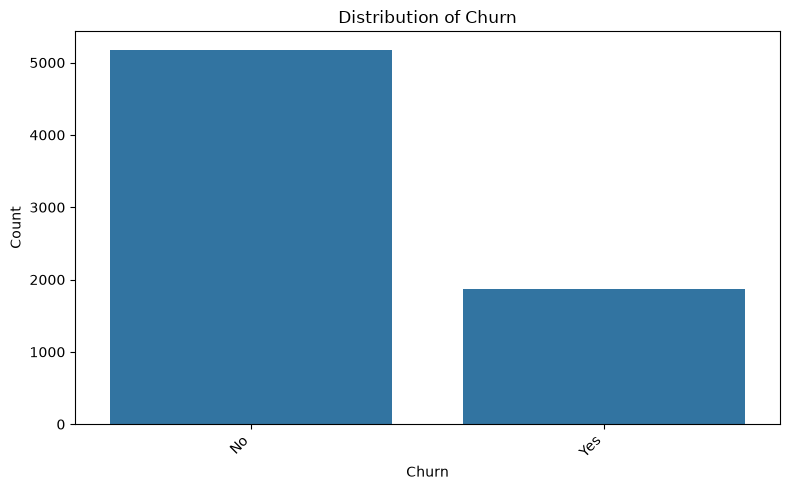

In [15]:
for col in categorical:
    plt.figure(figsize=(8, 5))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

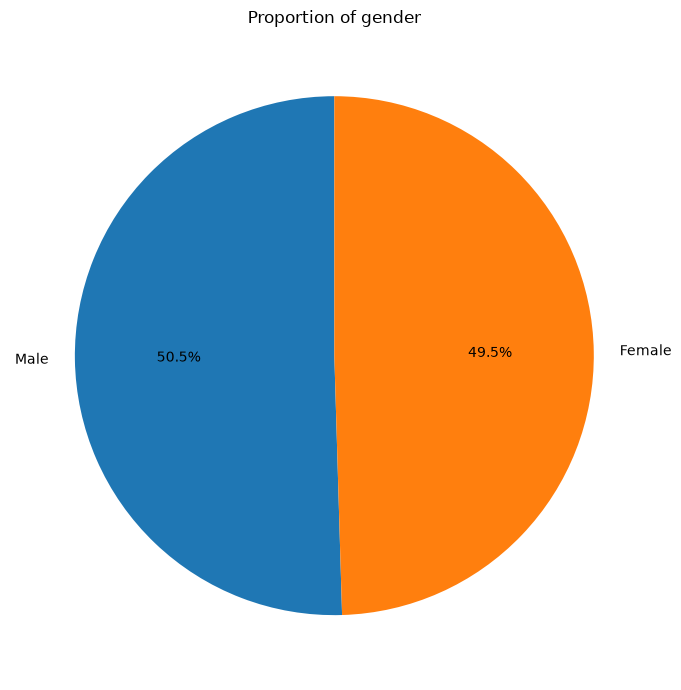

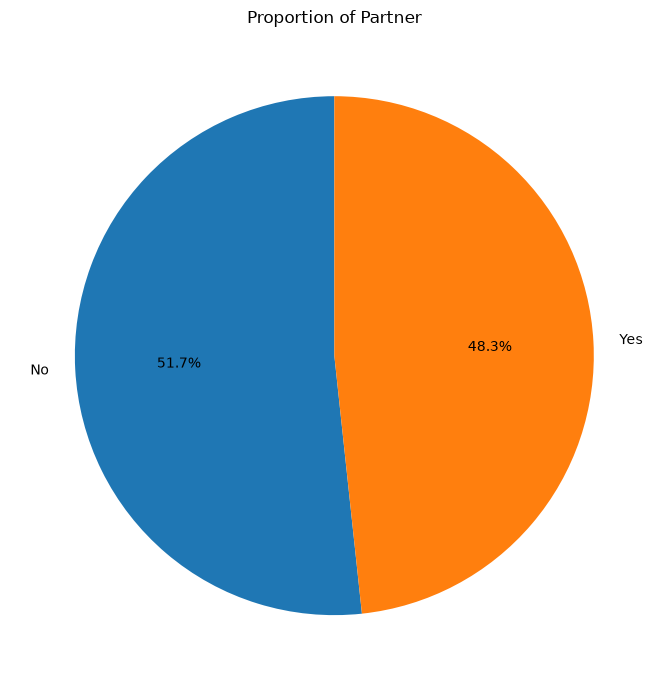

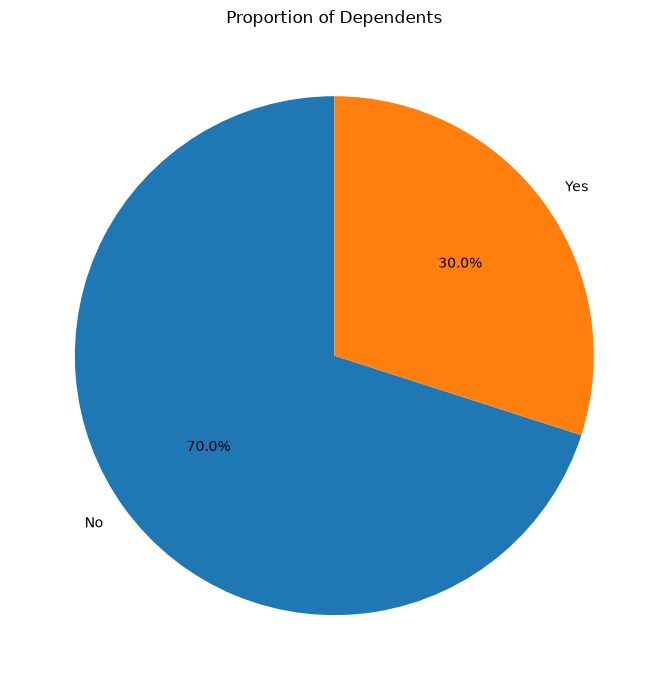

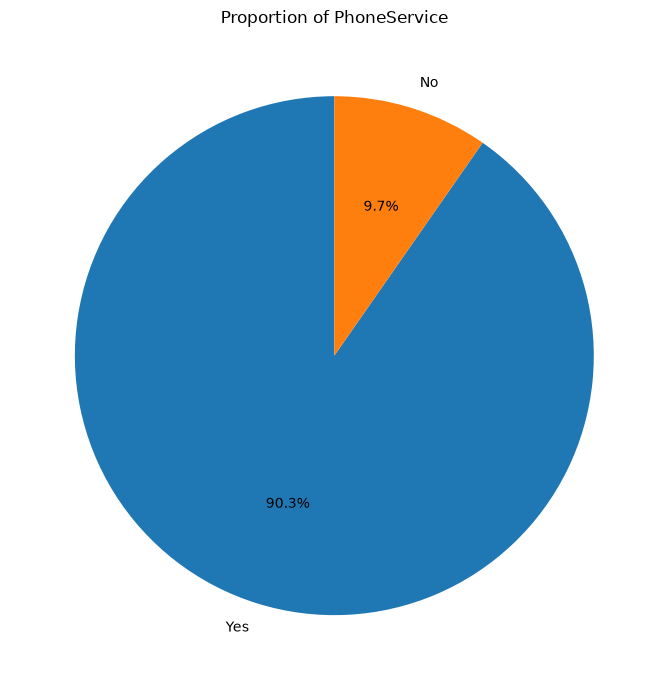

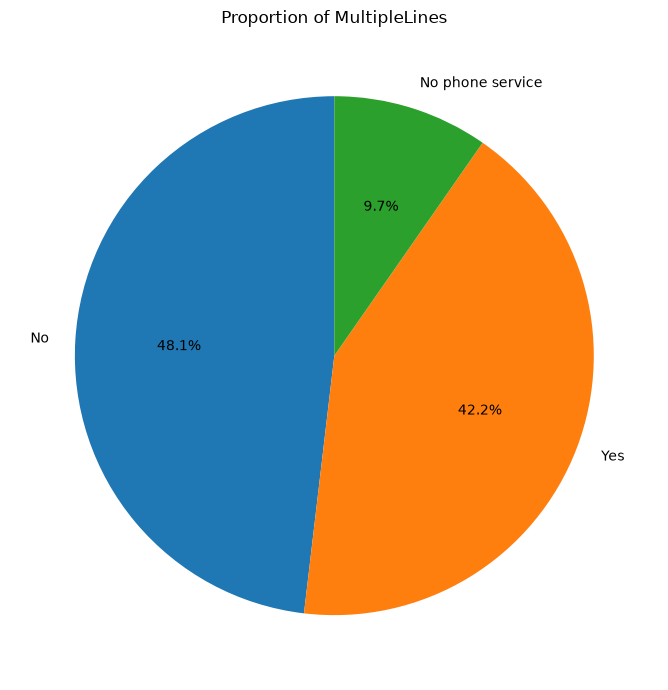

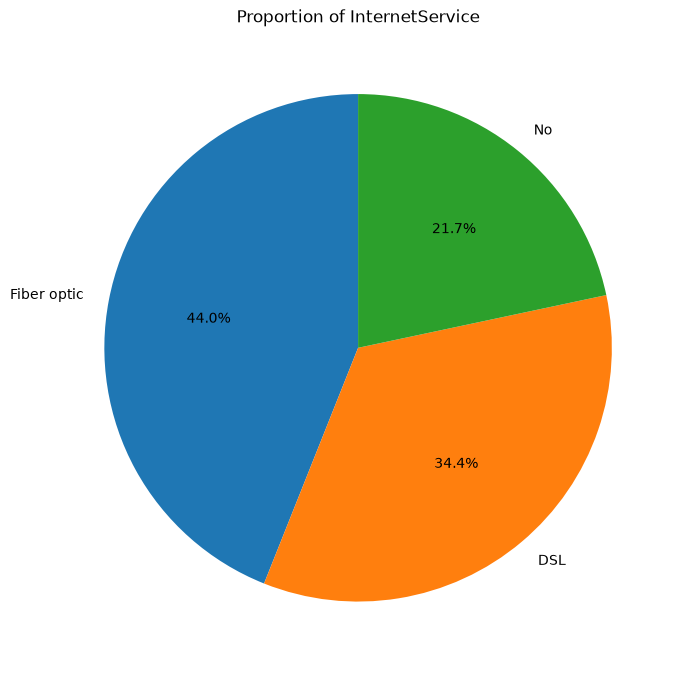

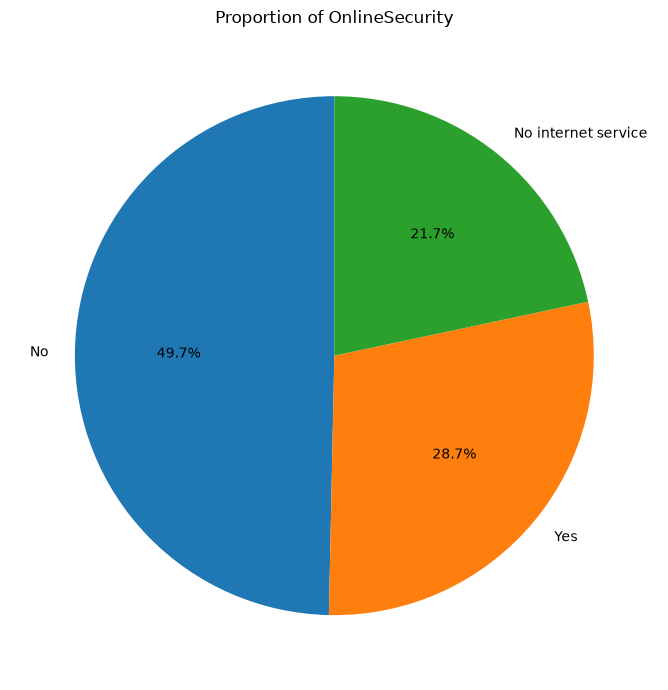

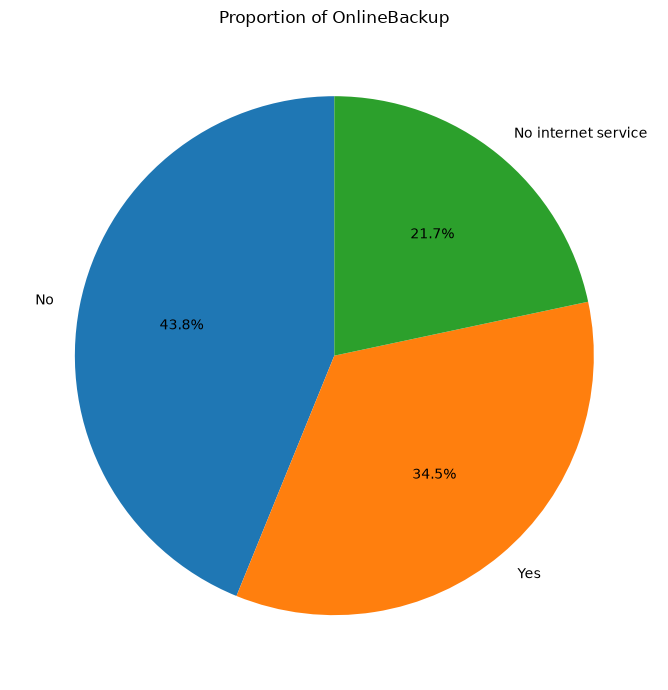

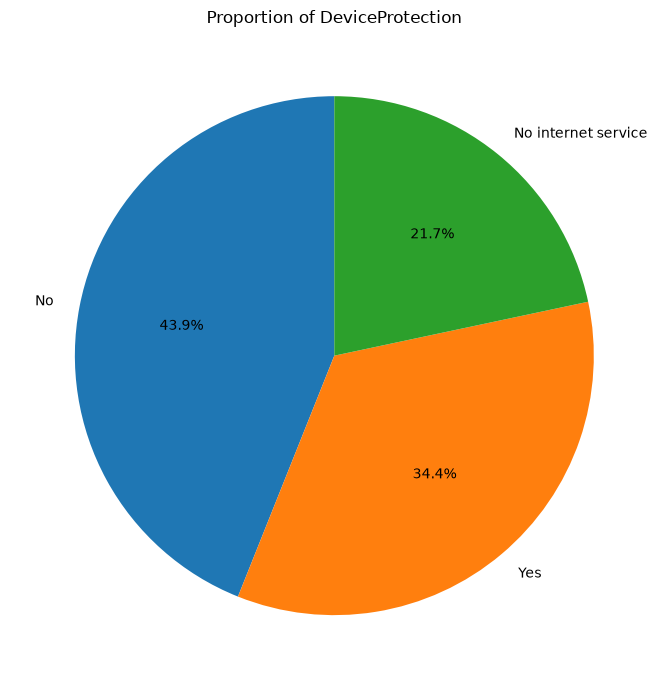

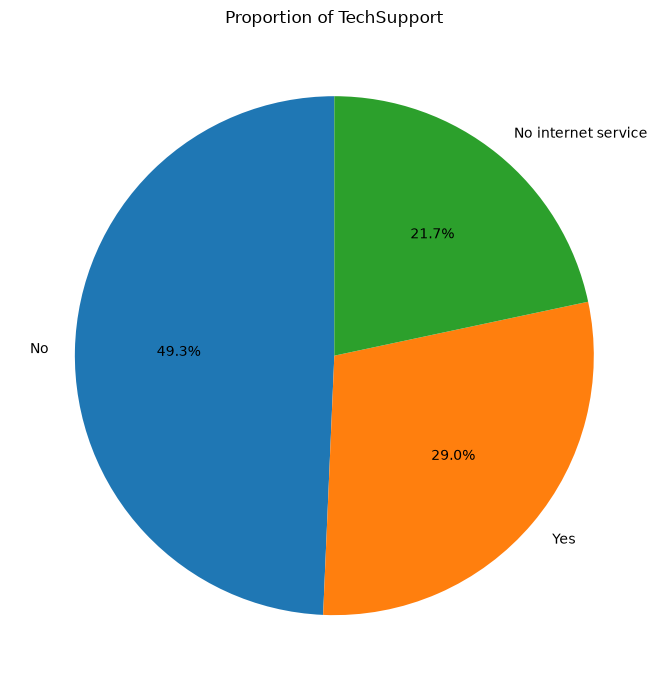

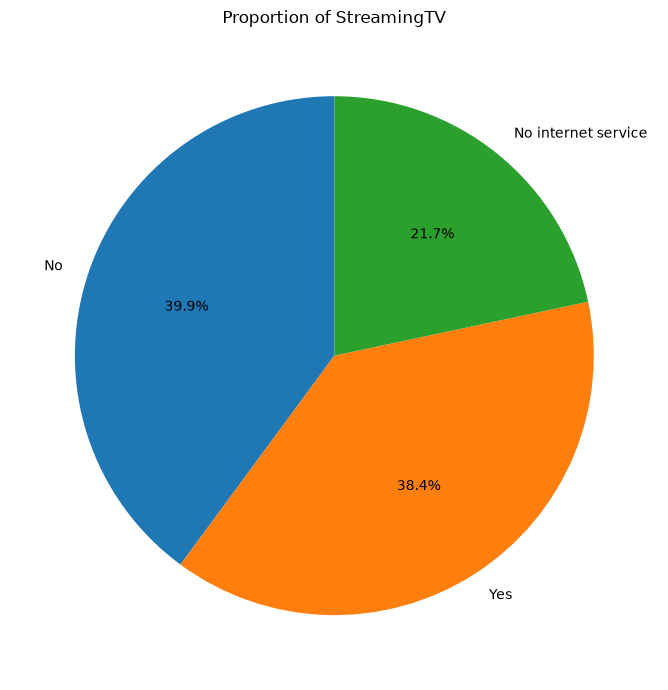

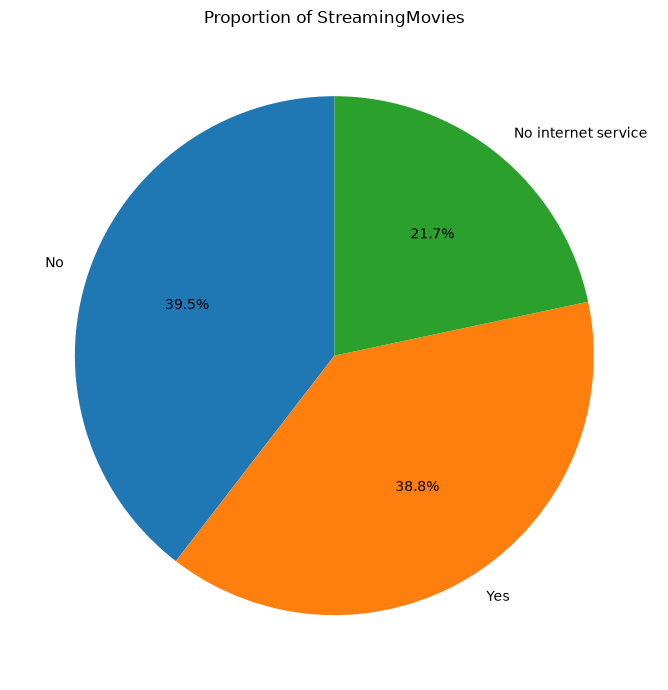

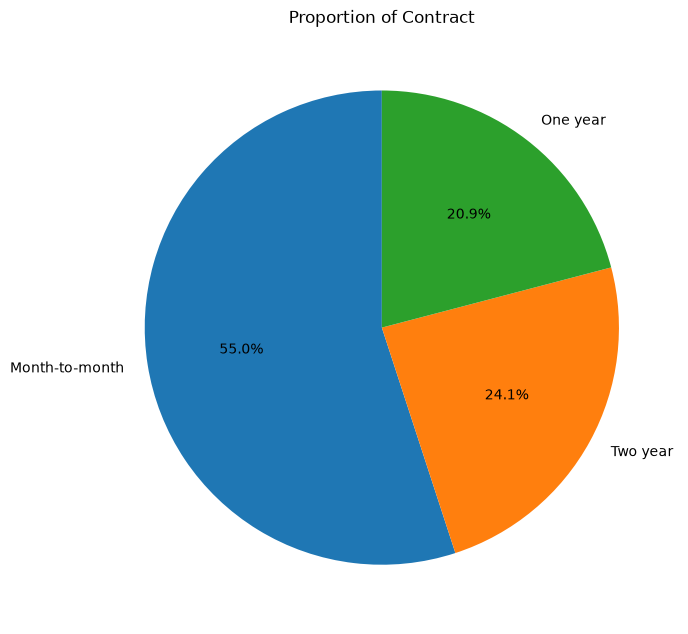

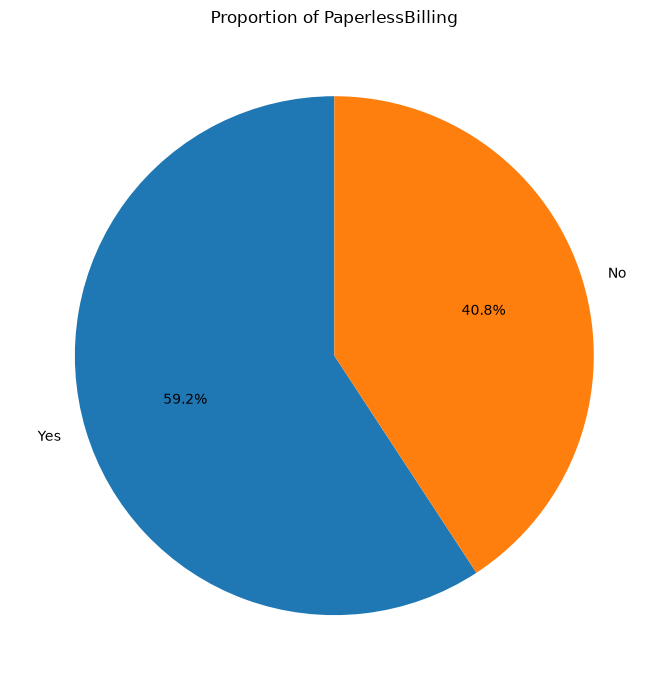

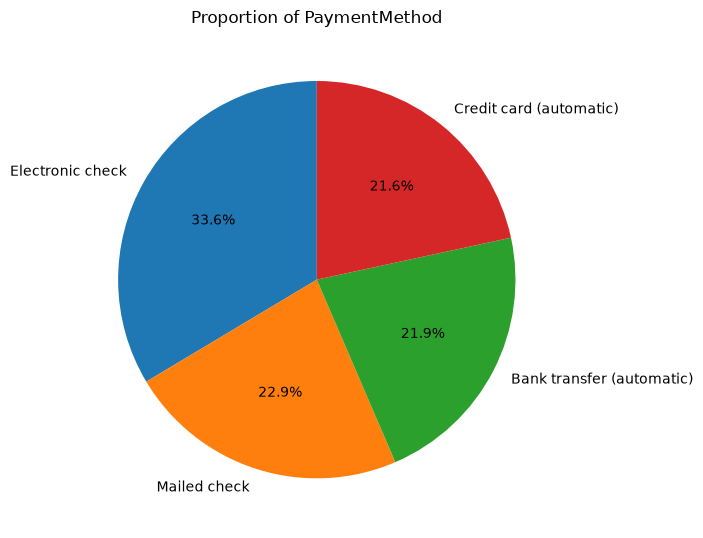

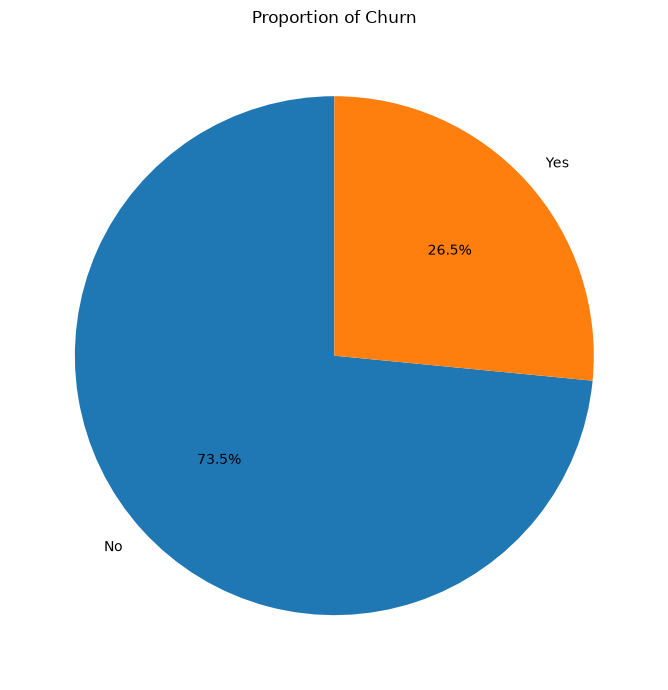

In [18]:
for col in categorical:
    counts = df[col].value_counts(dropna=False)
    plt.figure(figsize=(7, 7))
    plt.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(f'Proportion of {col}')
    plt.tight_layout()
    plt.show()

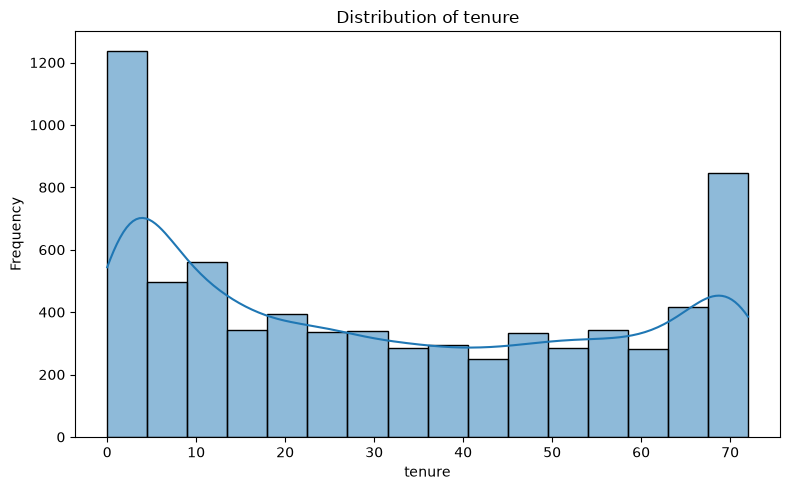

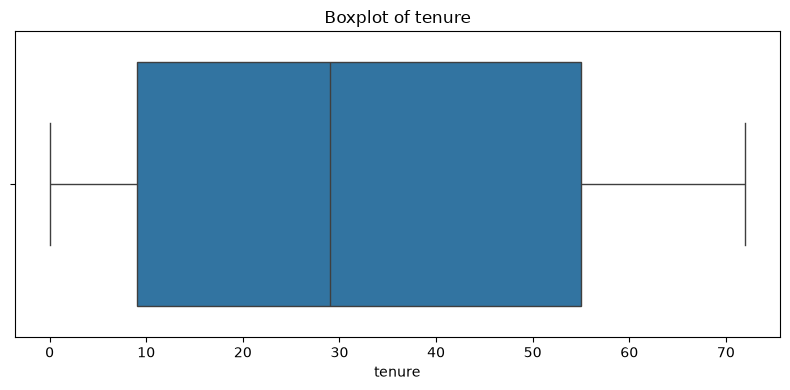

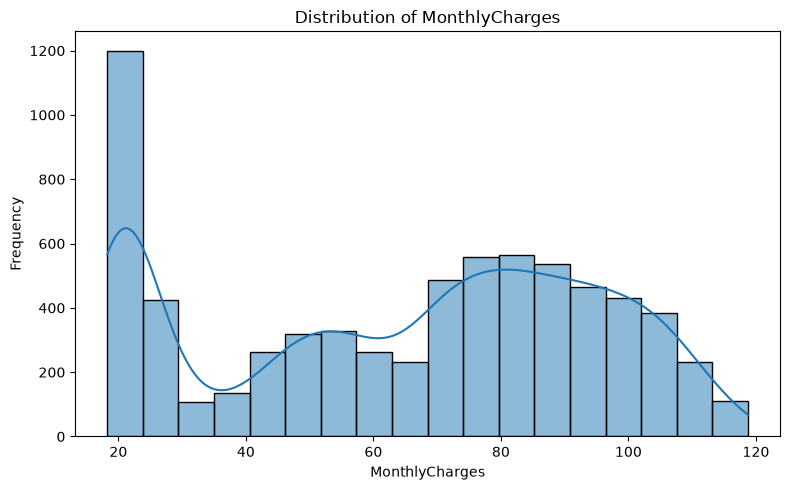

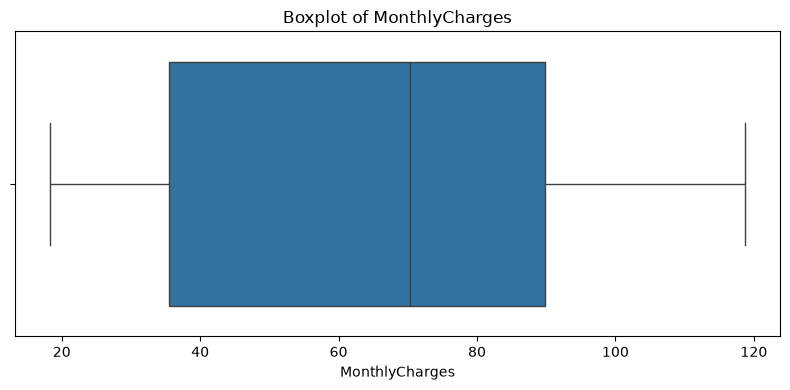

In [19]:
for col in continuous:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


<Figure size 800x500 with 0 Axes>

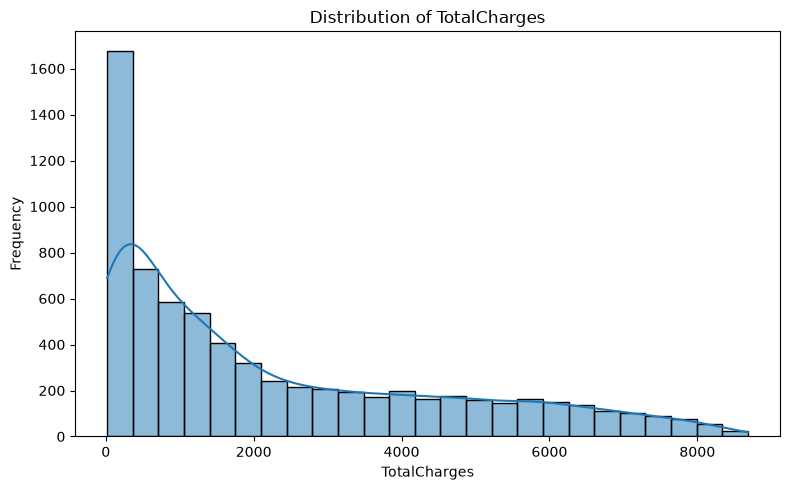

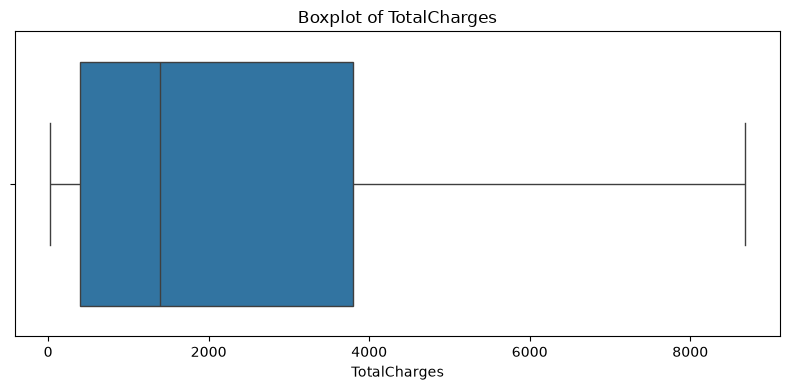

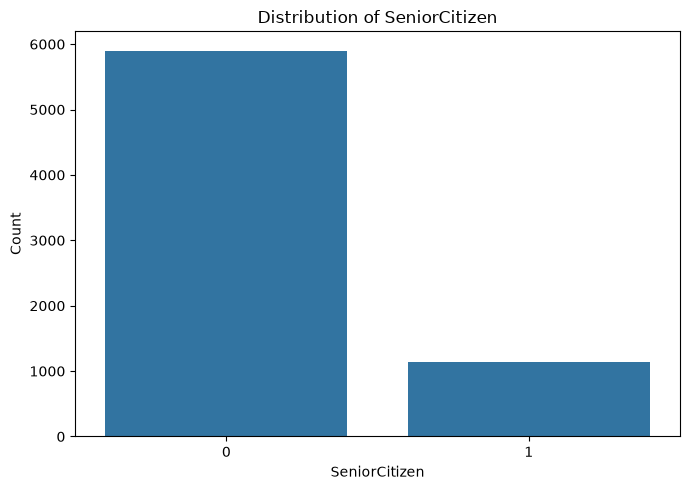

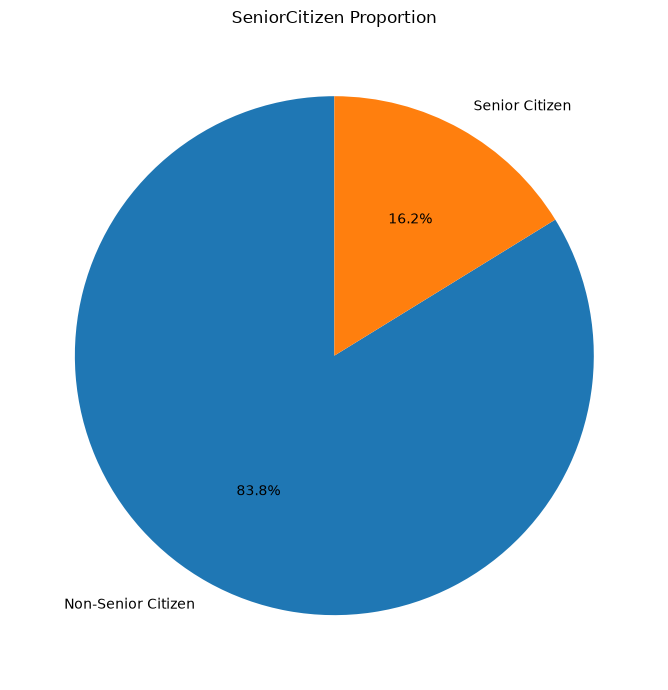

In [21]:
plt.figure(figsize=(8, 5))
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalCharges'].dropna(), kde=True)
plt.title('Distribution of TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalCharges'])
plt.title('Boxplot of TotalCharges')
plt.xlabel('TotalCharges')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='SeniorCitizen')
plt.title('Distribution of SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

counts = df['SeniorCitizen'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    counts.values,
    labels=['Non-Senior Citizen', 'Senior Citizen'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('SeniorCitizen Proportion')
plt.tight_layout()
plt.show()



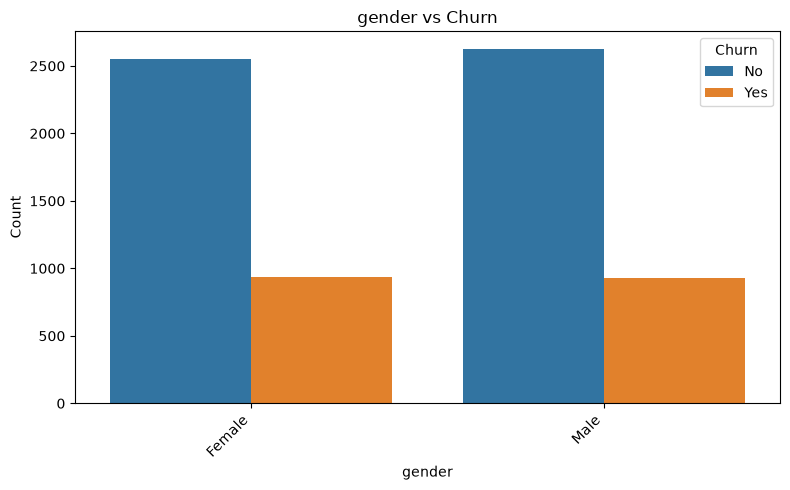

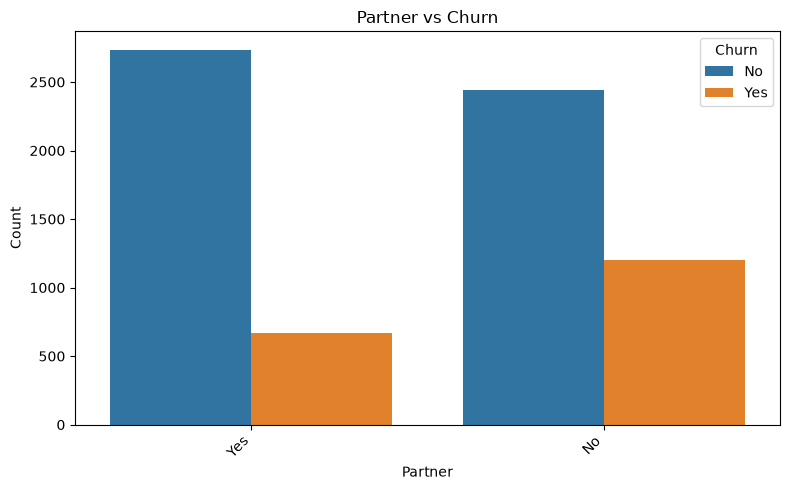

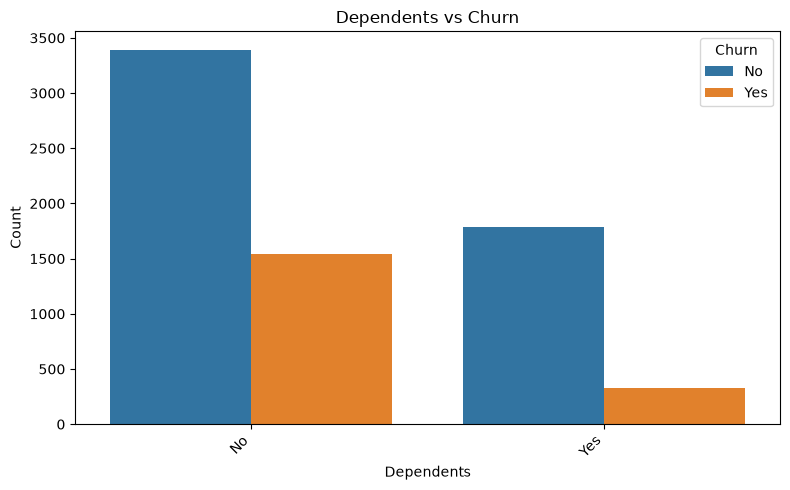

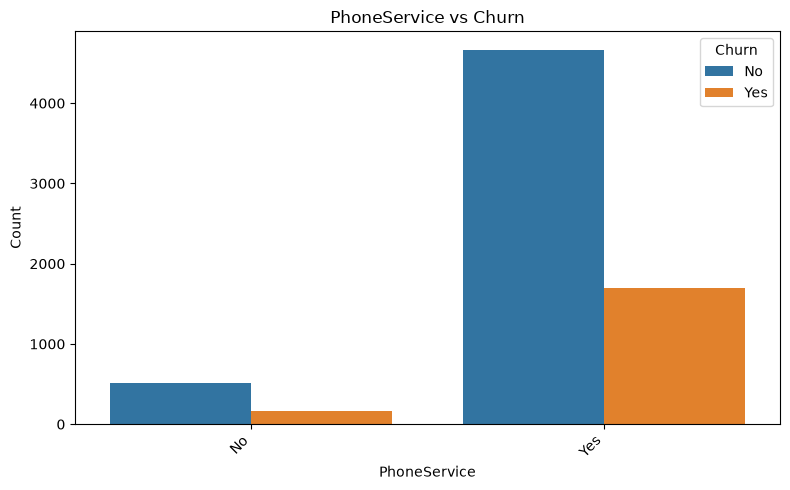

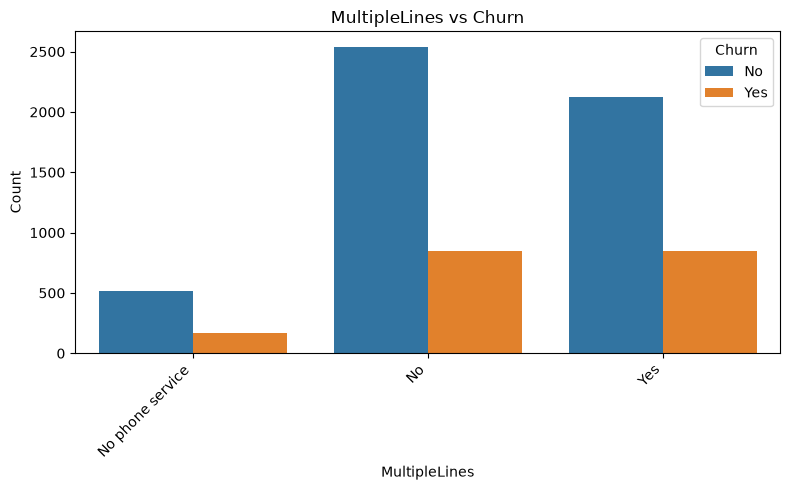

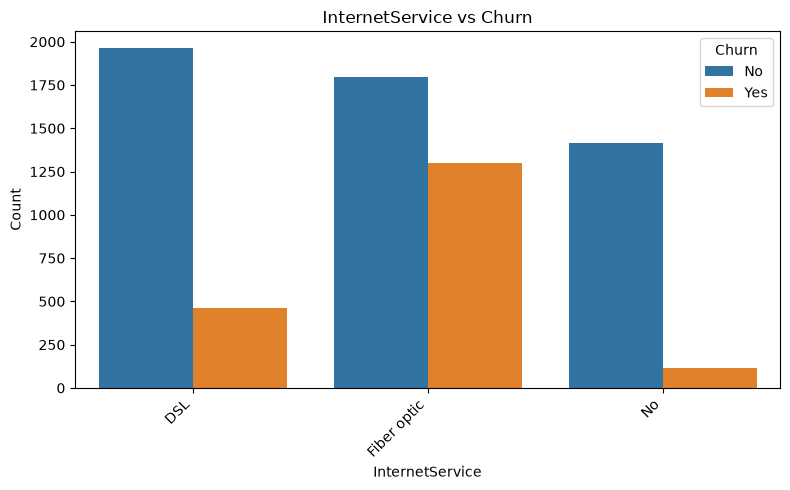

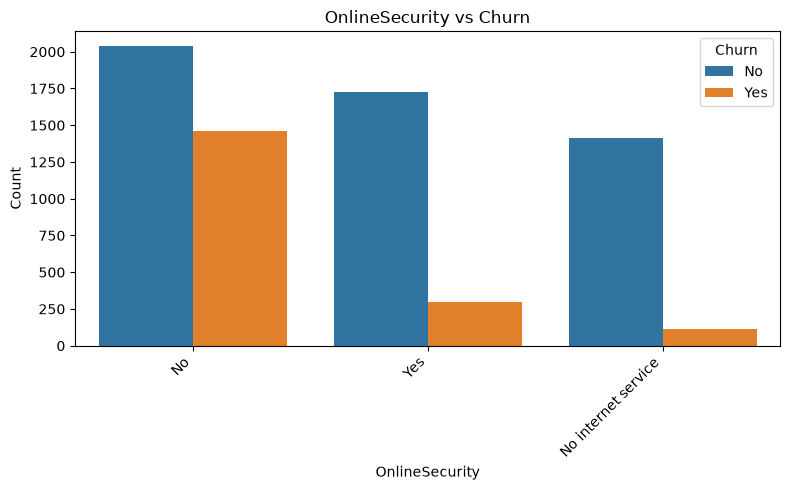

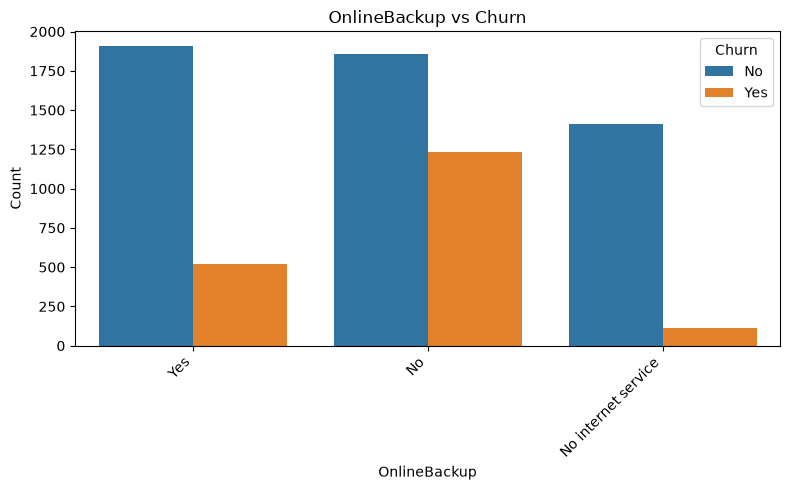

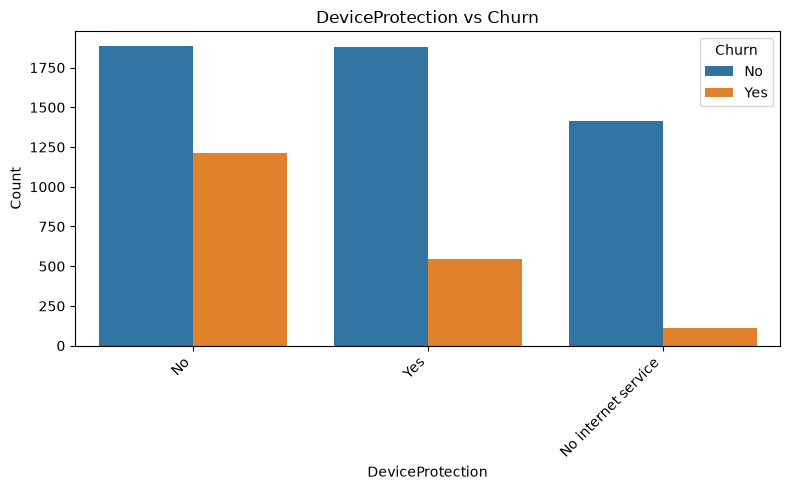

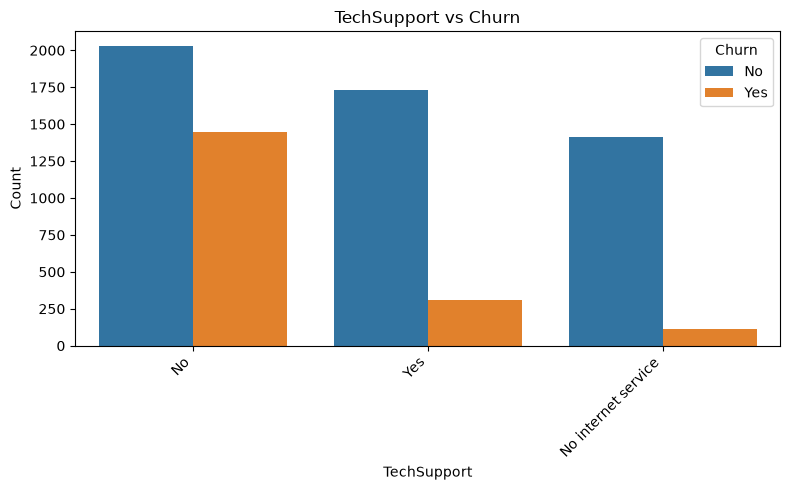

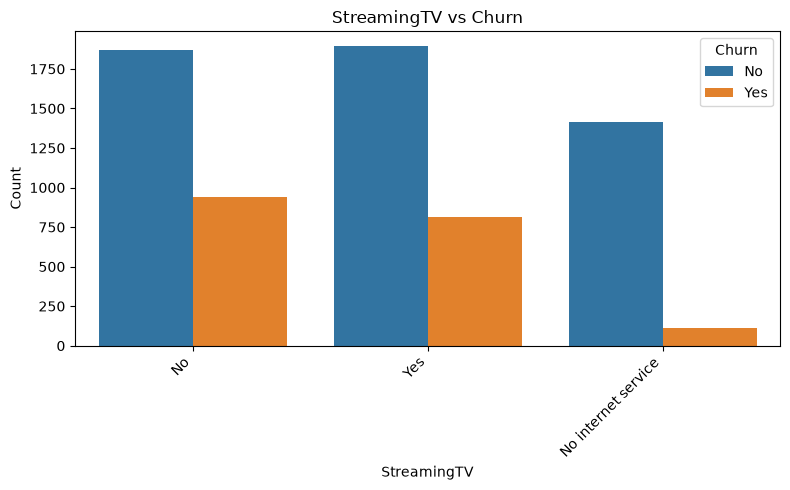

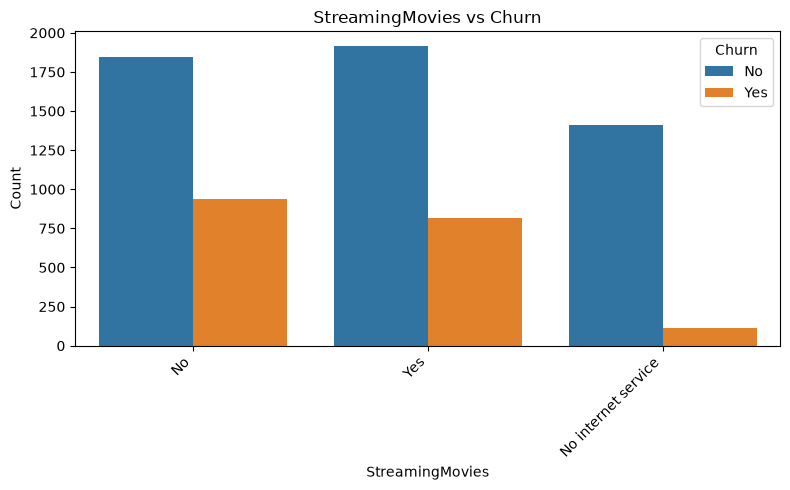

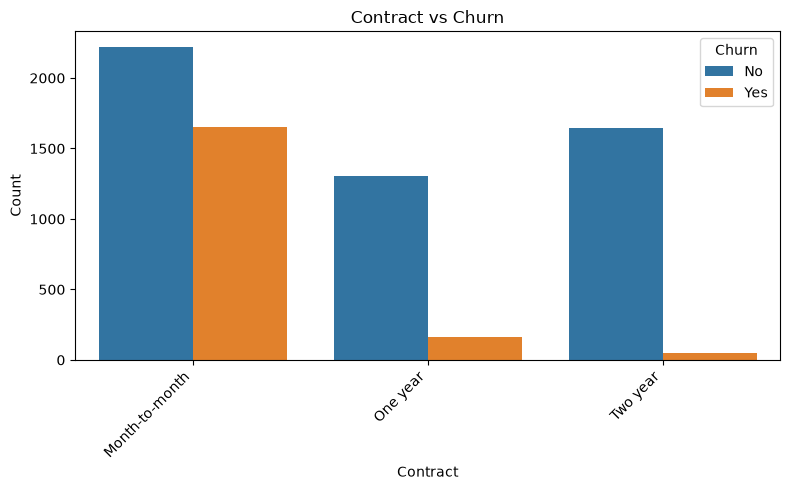

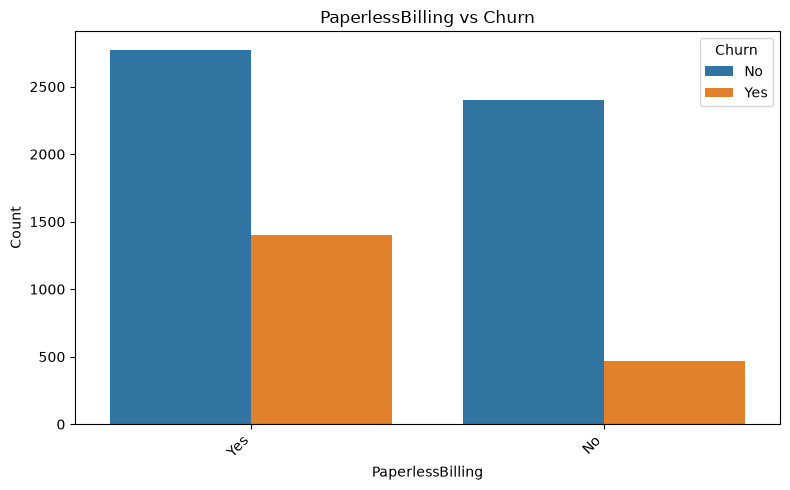

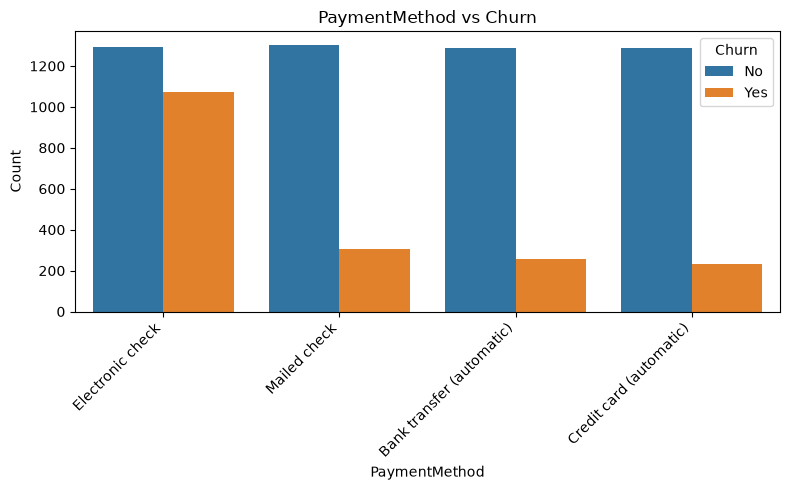

In [22]:
for col in categorical:
    if col != 'Churn':
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, hue='Churn')
        plt.title(f'{col} vs Churn')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Churn')
        plt.tight_layout()
        plt.show()

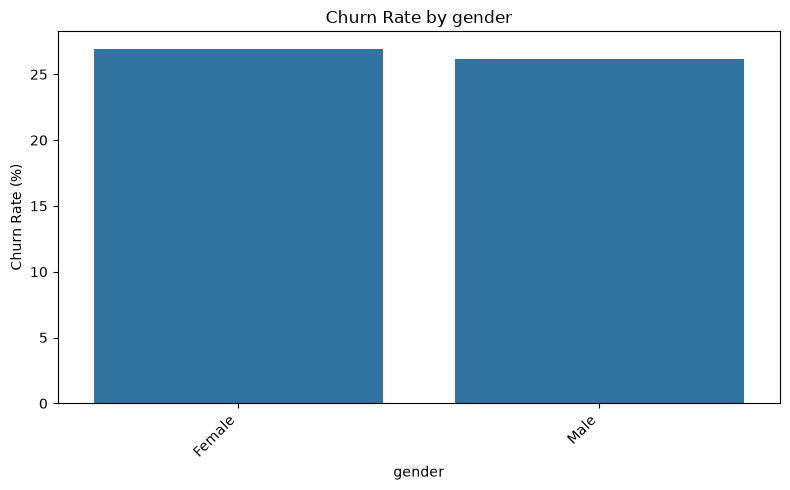

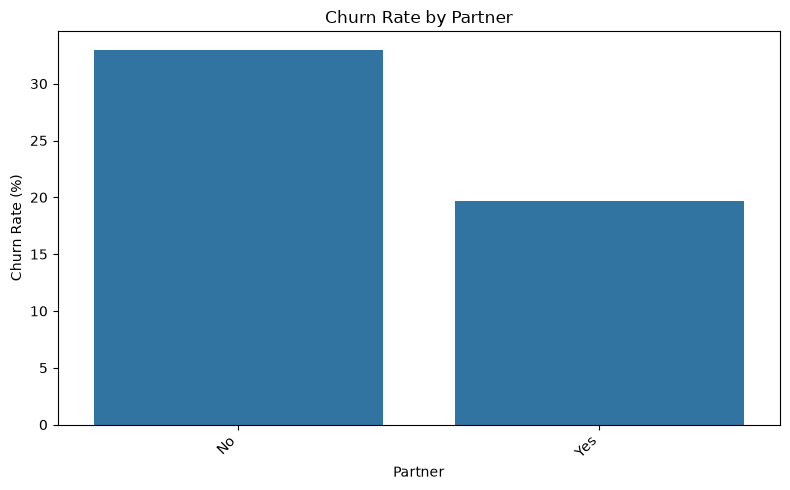

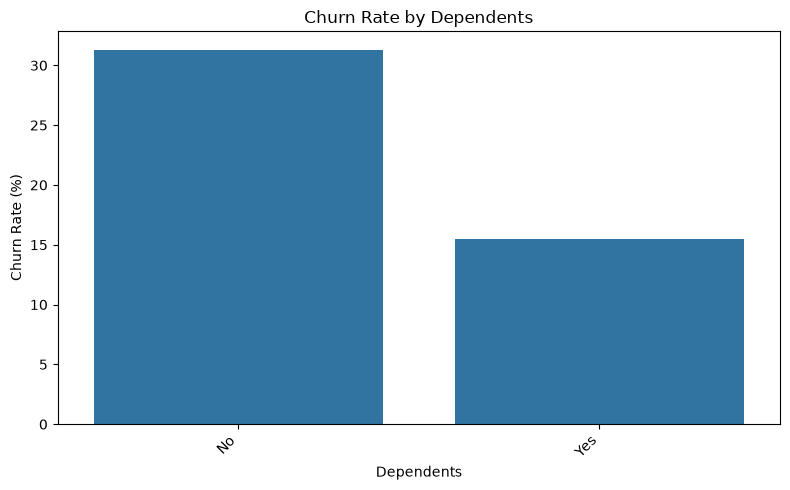

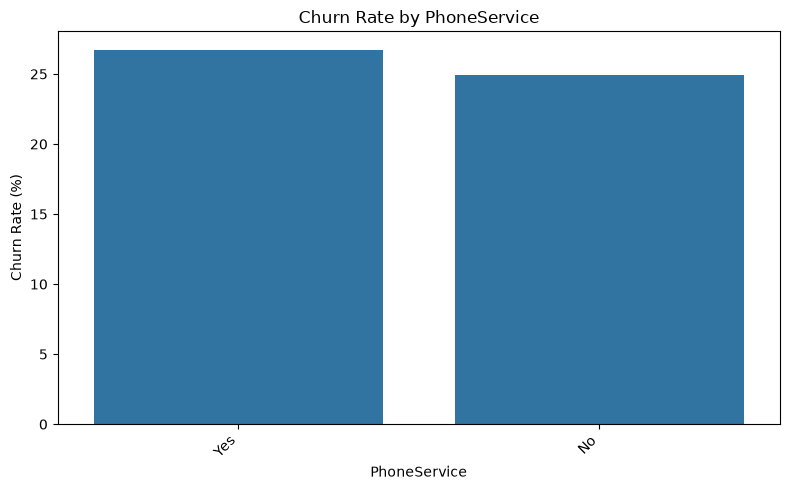

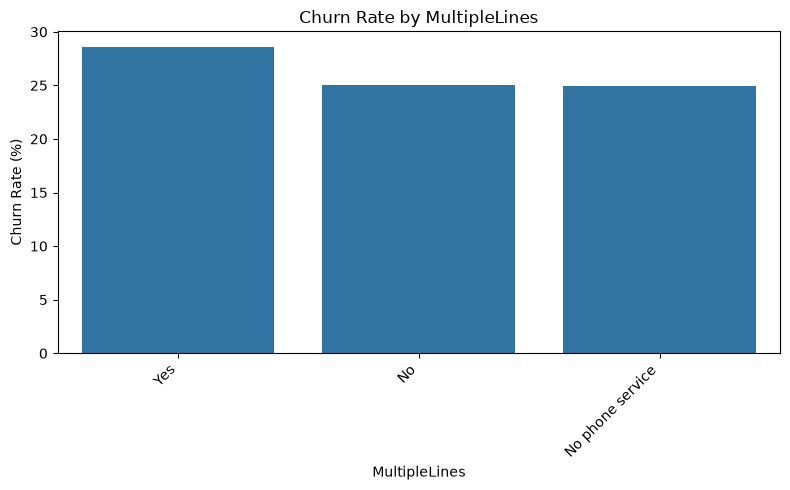

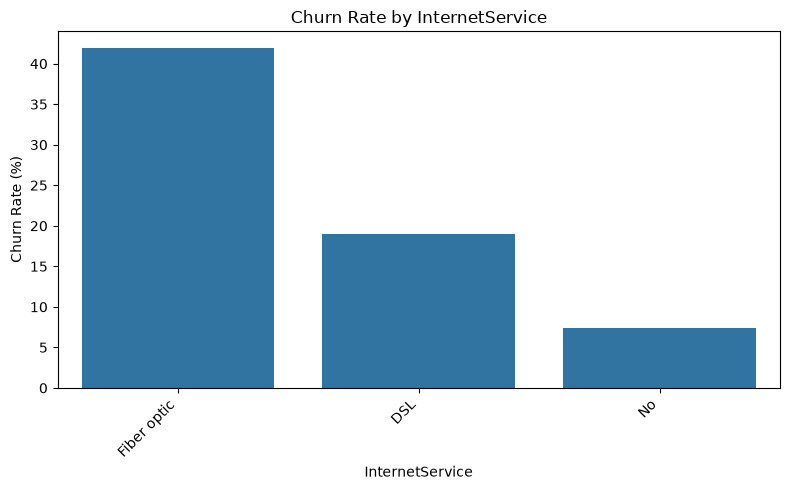

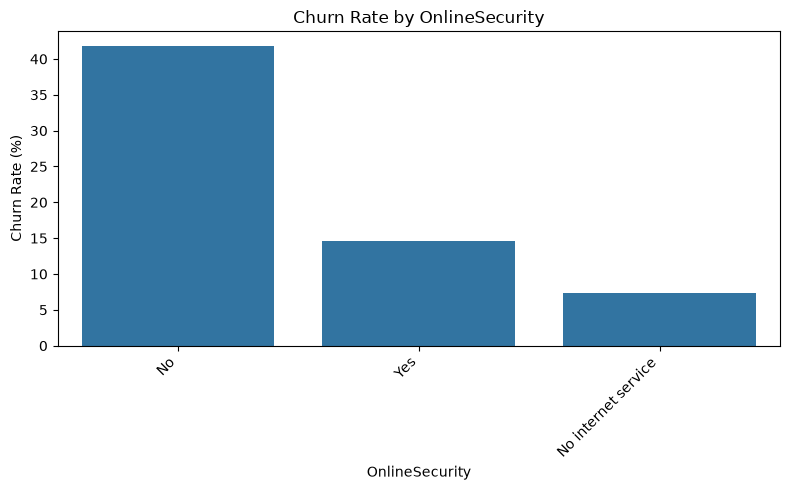

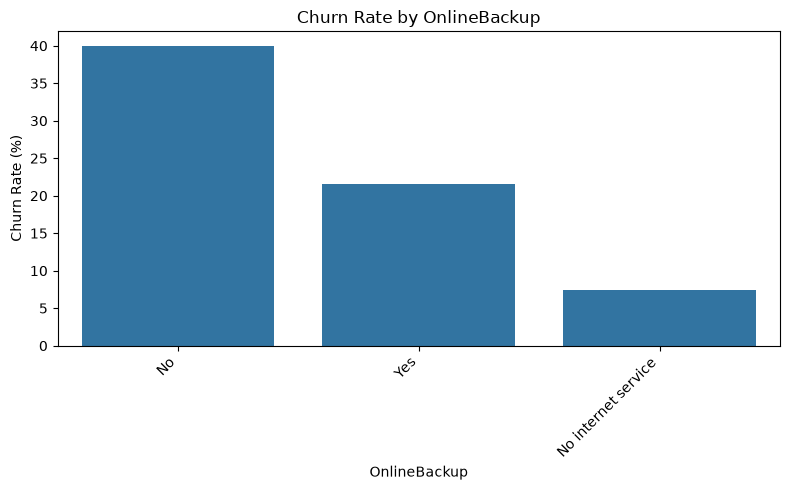

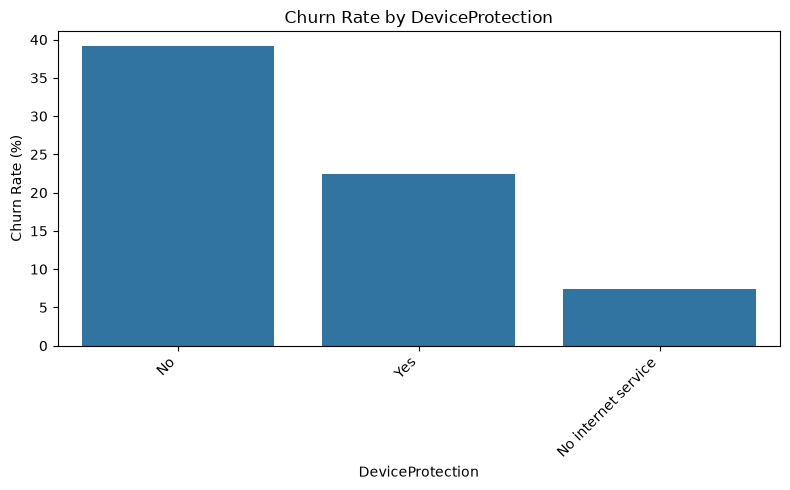

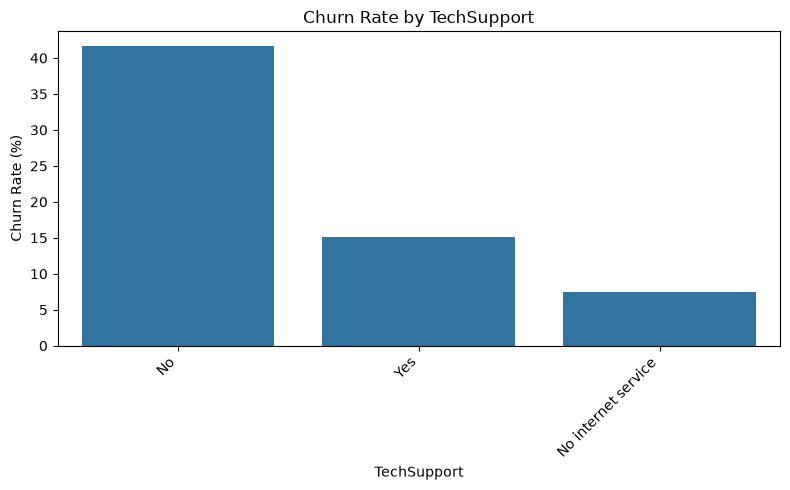

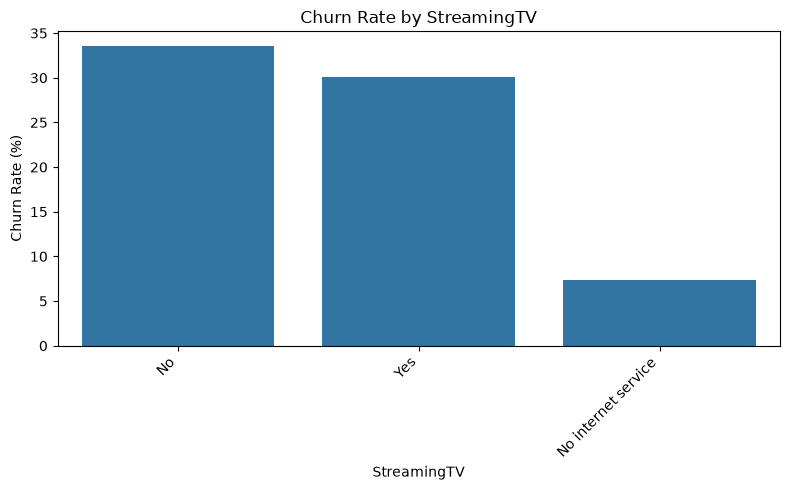

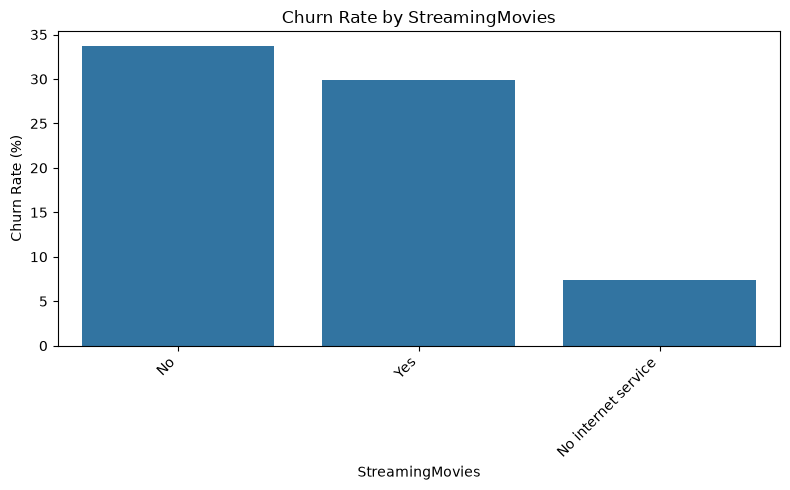

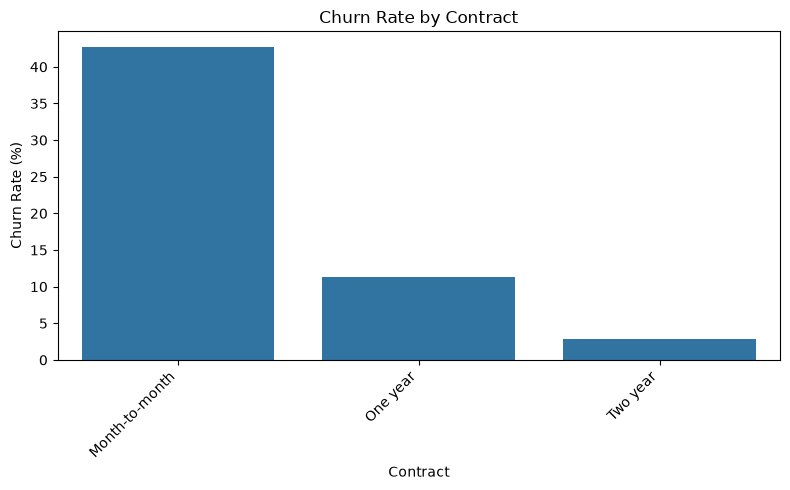

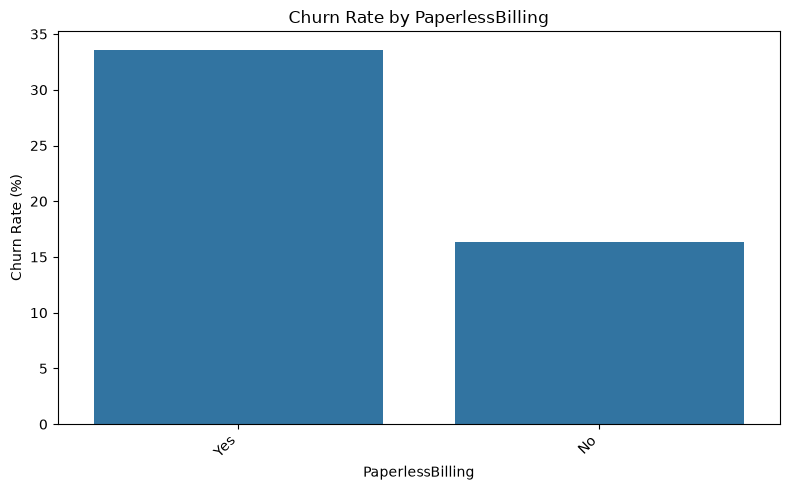

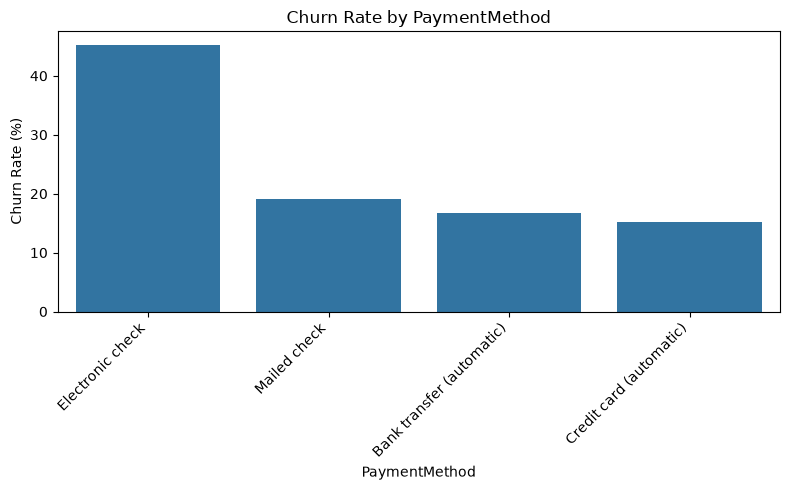

In [24]:
for col in categorical:
    if col != 'Churn':
        churn_rate = pd.crosstab(
            df[col],
            df['Churn'],
            normalize='index'
        ) * 100

        if 'Yes' in churn_rate.columns:
            churn_rate = churn_rate['Yes'].sort_values(ascending=False)

            plt.figure(figsize=(8, 5))
            sns.barplot(
                x=churn_rate.index,
                y=churn_rate.values
            )
            plt.title(f'Churn Rate by {col}')
            plt.xlabel(col)
            plt.ylabel('Churn Rate (%)')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

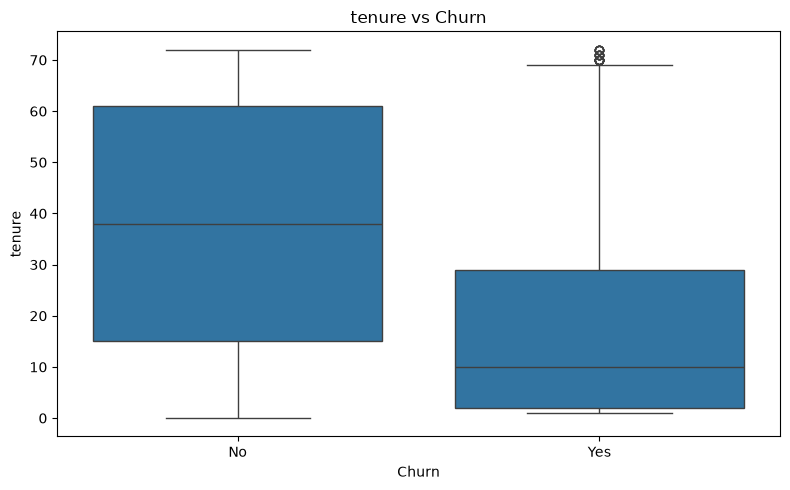

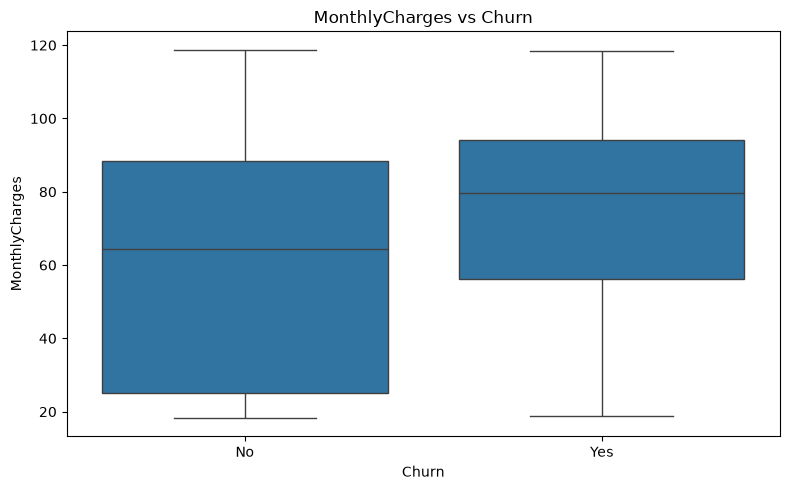

In [25]:
for col in continuous:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

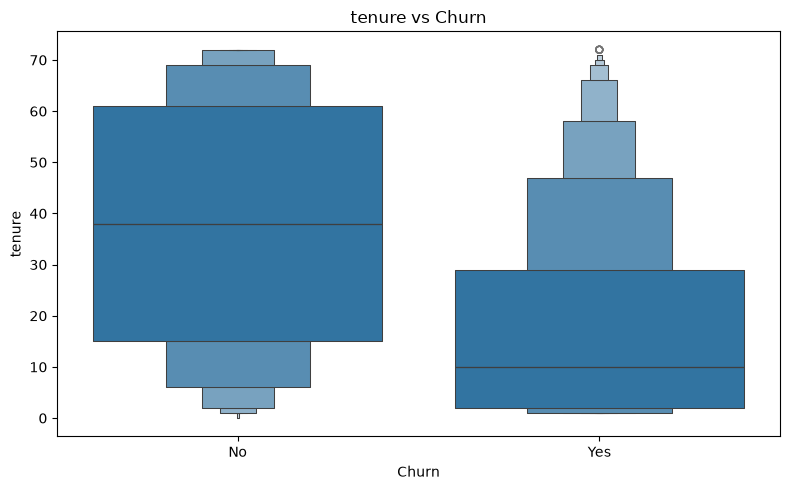

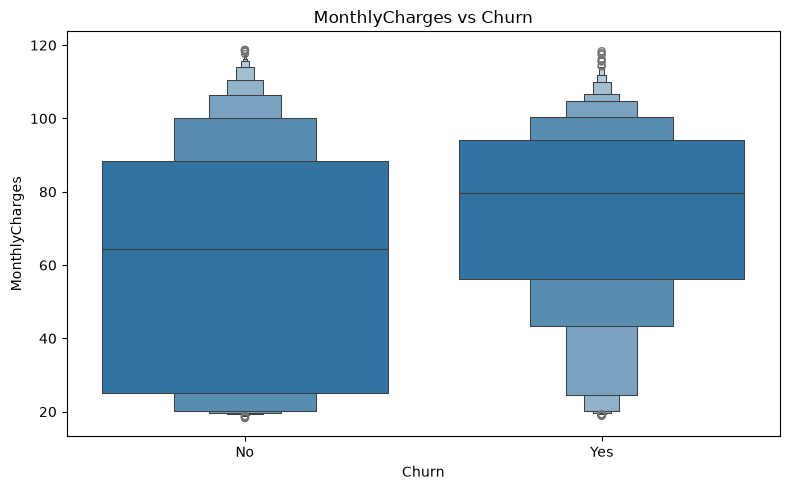

In [26]:
for col in continuous:
    plt.figure(figsize=(8, 5))
    sns.boxenplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

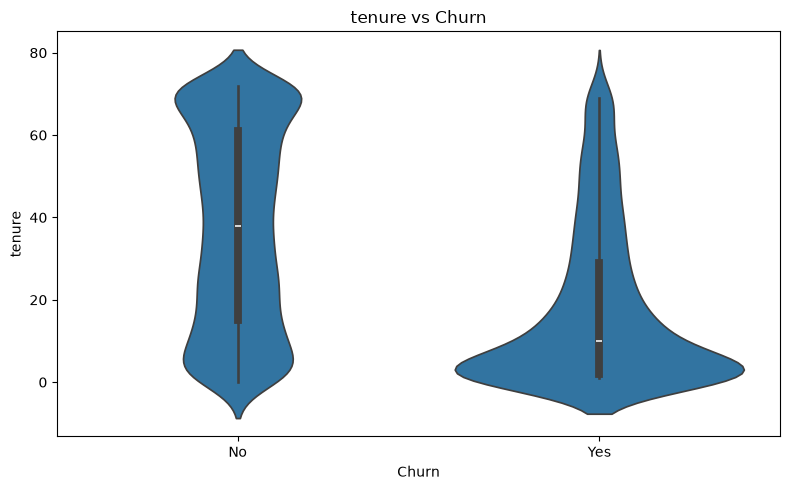

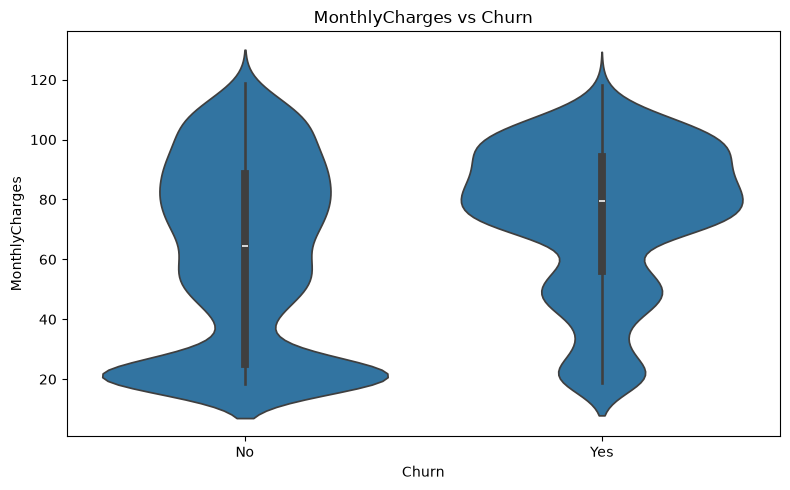

In [27]:
for col in continuous:
    plt.figure(figsize=(8, 5))
    sns.violinplot(data=df, x='Churn', y=col)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

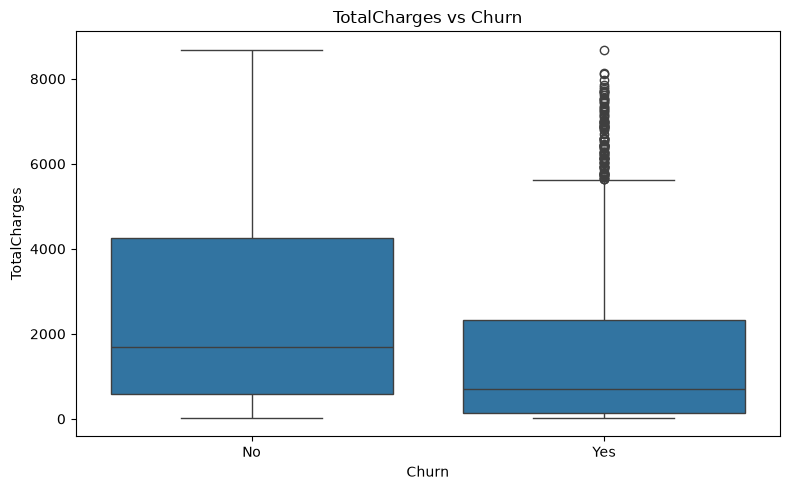

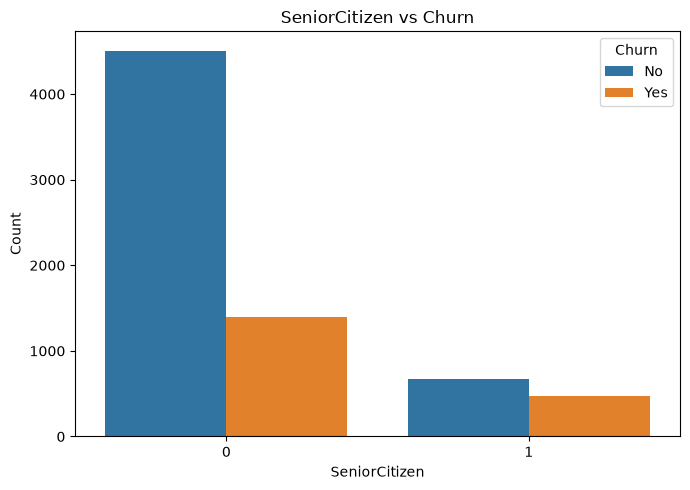

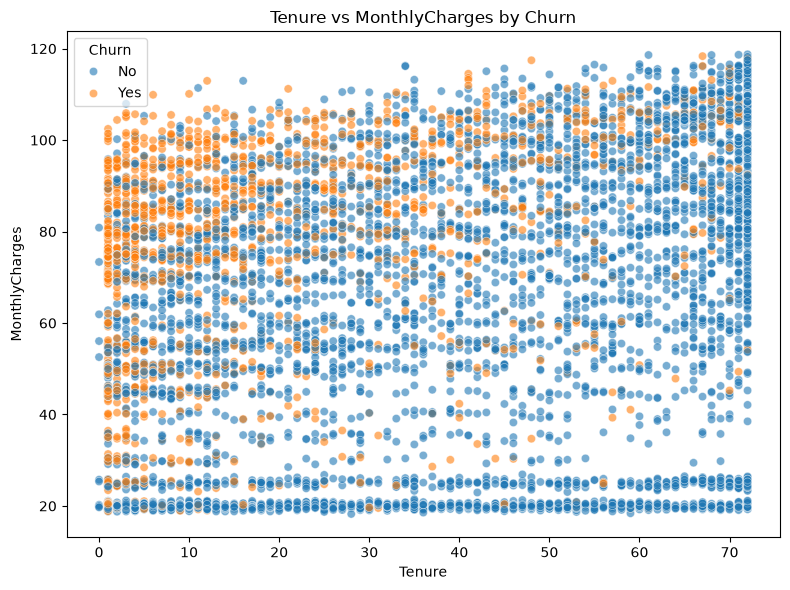

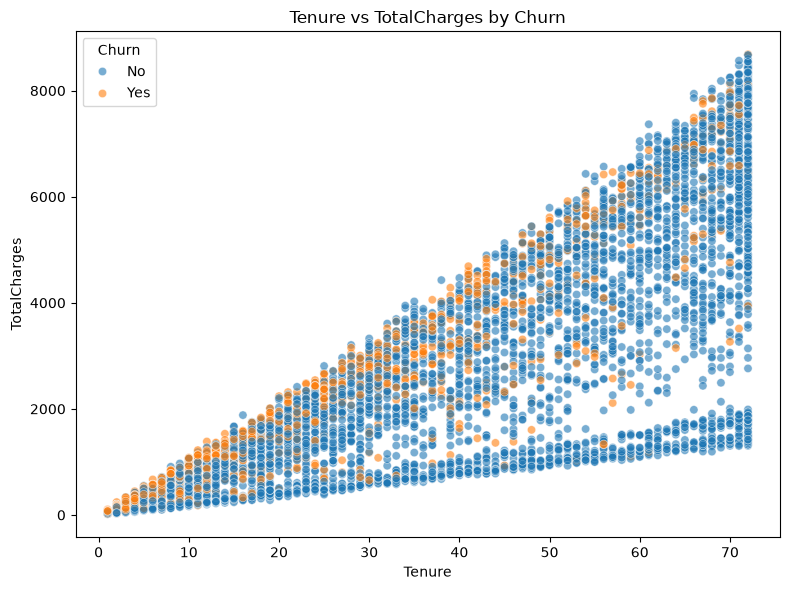

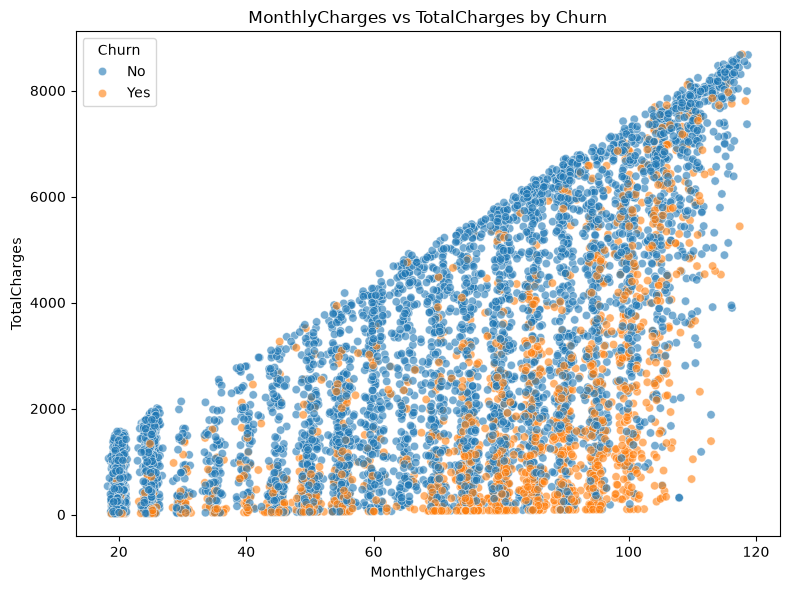

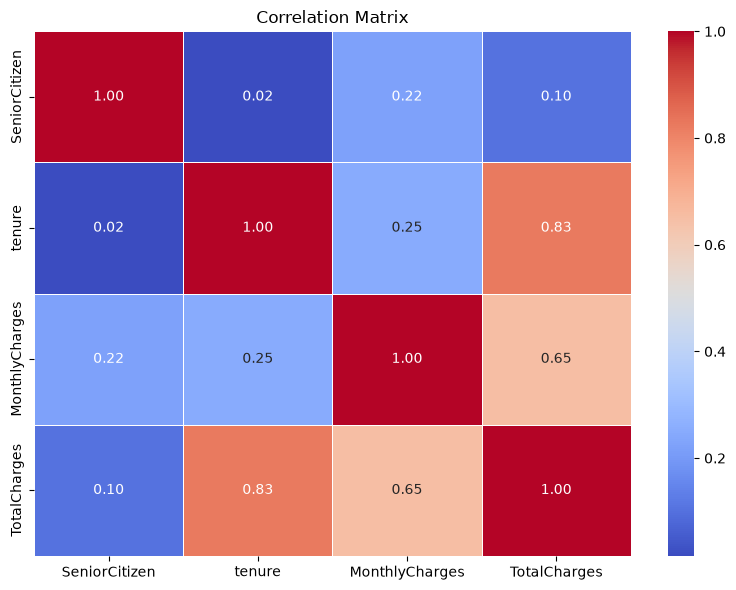

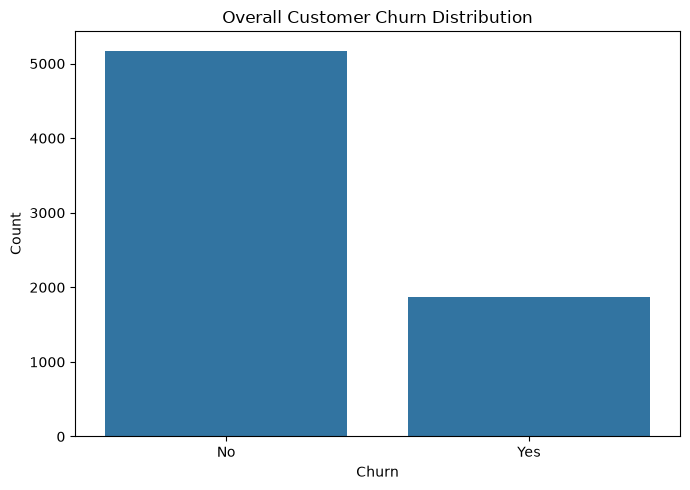

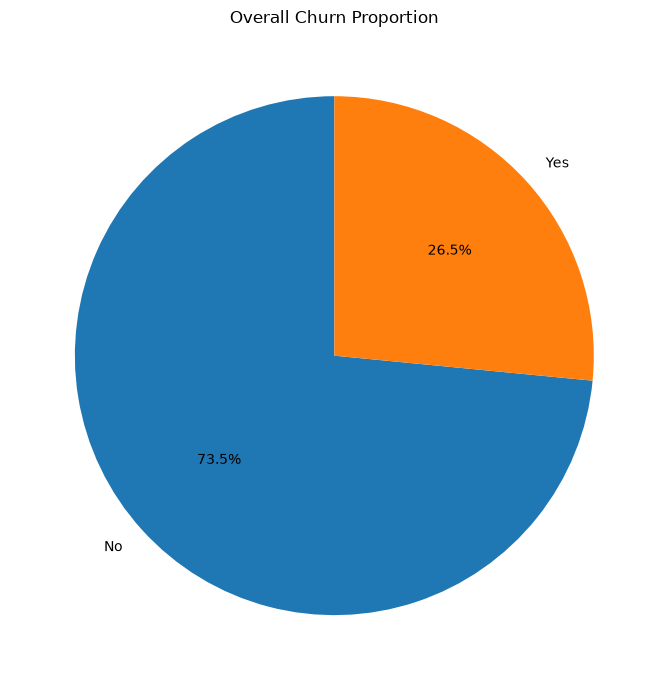

In [28]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='TotalCharges')
plt.title('TotalCharges vs Churn')
plt.xlabel('Churn')
plt.ylabel('TotalCharges')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title('SeniorCitizen vs Churn')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.6
)
plt.title('Tenure vs MonthlyCharges by Churn')
plt.xlabel('Tenure')
plt.ylabel('MonthlyCharges')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    alpha=0.6
)
plt.title('Tenure vs TotalCharges by Churn')
plt.xlabel('Tenure')
plt.ylabel('TotalCharges')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    alpha=0.6
)
plt.title('MonthlyCharges vs TotalCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('TotalCharges')
plt.tight_layout()
plt.show()

numeric_features = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Churn')
plt.title('Overall Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Overall Churn Proportion')
plt.tight_layout()
plt.show()

In [29]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

numeric_features = ['tenure','MonthlyCharges','TotalCharges']

print(df[numeric_features].describe().T)
print('\nMissing values:')
print(df[numeric_features].isnull().sum())


                 count         mean          std    min     25%       50%  \
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350   
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475   

                      75%      max  
tenure            55.0000    72.00  
MonthlyCharges    89.8500   118.75  
TotalCharges    3794.7375  8684.80  

Missing values:
tenure             0
MonthlyCharges     0
TotalCharges      11
dtype: int64


In [30]:
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5* IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        'Feature':col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': len(outliers) / len(df) * 100
        
    })

outlier_summary = pd.DataFrame(outlier_summary)
print(outlier_summary)

          Feature      Q1         Q3        IQR  Lower_Bound  Upper_Bound  \
0          tenure    9.00    55.0000    46.0000    -60.00000    124.00000   
1  MonthlyCharges   35.50    89.8500    54.3500    -46.02500    171.37500   
2    TotalCharges  401.45  3794.7375  3393.2875  -4688.48125   8884.66875   

   Outlier_Count  Outlier_Percentage  
0              0                 0.0  
1              0                 0.0  
2              0                 0.0  


In [31]:
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f'\n{col}')
    print(f'Lower Bound: {lower:.2f}')
    print(f'Upper Bound: {upper:.2f}')
    print(f'Number of Outliers: {len(outliers)}')
    print(outliers[col].sort_values().values)


tenure
Lower Bound: -60.00
Upper Bound: 124.00
Number of Outliers: 0
[]

MonthlyCharges
Lower Bound: -46.02
Upper Bound: 171.38
Number of Outliers: 0
[]

TotalCharges
Lower Bound: -4688.48
Upper Bound: 8884.67
Number of Outliers: 0
[]


In [32]:
df_clean = df.copy()

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

df_clean = df_clean.reset_index(drop=True)

print('Original shape:', df.shape)
print('Cleaned shape:', df_clean.shape)
print('Rows removed:', len(df) - len(df_clean))
print('Percentage removed:', ((len(df) - len(df_clean)) / len(df)) * 100)

Original shape: (7043, 20)
Cleaned shape: (7032, 20)
Rows removed: 11
Percentage removed: 0.1561834445548772


In [33]:
df_corr = df_clean.copy()

binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

for col in binary_cols:
    df_corr[col] = df_corr[col].map(
        {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
    )

multi_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_corr = pd.get_dummies(
    df_corr,
    columns=multi_cols,
    drop_first=False,
    dtype=int
)

correlation = (
    df_corr.corr(numeric_only=True)['Churn']
    .drop('Churn')
    .sort_values(ascending=False)
)

print(correlation.to_string())

Contract_Month-to-month                    0.404565
OnlineSecurity_No                          0.342235
TechSupport_No                             0.336877
InternetService_Fiber optic                0.307463
PaymentMethod_Electronic check             0.301455
OnlineBackup_No                            0.267595
DeviceProtection_No                        0.252056
MonthlyCharges                             0.192858
PaperlessBilling                           0.191454
SeniorCitizen                              0.150541
StreamingMovies_No                         0.130920
StreamingTV_No                             0.128435
StreamingTV_Yes                            0.063254
StreamingMovies_Yes                        0.060860
MultipleLines_Yes                          0.040033
PhoneService                               0.011691
gender                                    -0.008545
MultipleLines_No phone service            -0.011691
MultipleLines_No                          -0.032654
DeviceProtec

In [34]:
correlation_table = pd.DataFrame({
    'Feature': correlation.index,
    'Correlation': correlation.values,
    'Absolute_Correlation': correlation.abs().values
})

correlation_table = correlation_table.sort_values(
    'Absolute_Correlation',
    ascending=False
).reset_index(drop=True)

print(correlation_table.to_string(index=False))

                                Feature  Correlation  Absolute_Correlation
                Contract_Month-to-month     0.404565              0.404565
                                 tenure    -0.354049              0.354049
                      OnlineSecurity_No     0.342235              0.342235
                         TechSupport_No     0.336877              0.336877
            InternetService_Fiber optic     0.307463              0.307463
                      Contract_Two year    -0.301552              0.301552
         PaymentMethod_Electronic check     0.301455              0.301455
                        OnlineBackup_No     0.267595              0.267595
                    DeviceProtection_No     0.252056              0.252056
        TechSupport_No internet service    -0.227578              0.227578
                     InternetService_No    -0.227578              0.227578
     OnlineSecurity_No internet service    -0.227578              0.227578
        StreamingTV_No in

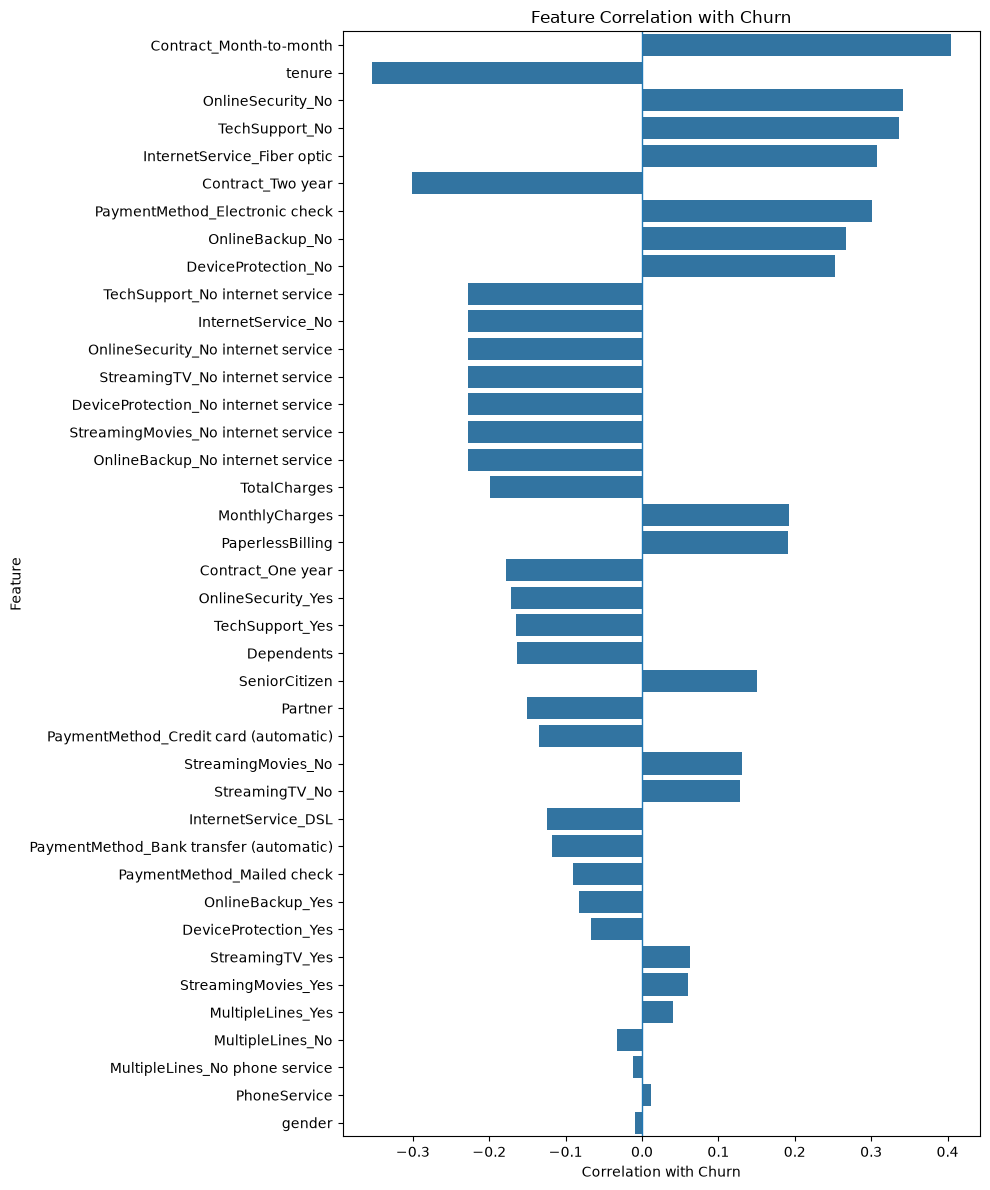

In [35]:
plt.figure(figsize=(10, 12))

sns.barplot(
    data=correlation_table,
    y='Feature',
    x='Correlation'
)

plt.axvline(0, linewidth=1)
plt.title('Feature Correlation with Churn')
plt.xlabel('Correlation with Churn')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [36]:
selected_features = [
    'Contract',
    'tenure',
    'OnlineSecurity',
    'TechSupport',
    'InternetService',
    'PaymentMethod',
    'OnlineBackup',
    'DeviceProtection',
    'TotalCharges',
    'MonthlyCharges',
    'PaperlessBilling',
    'Dependents',
    'SeniorCitizen',
    'Partner',
    'Churn'
]

df_selected = df_clean[selected_features].copy()

print('Original shape:', df_clean.shape)
print('Selected shape:', df_selected.shape)

print('\nSelected features:')
print(df_selected.columns.tolist())

print('\nFirst 5 rows:')
display(df_selected.head())

Original shape: (7032, 20)
Selected shape: (7032, 15)

Selected features:
['Contract', 'tenure', 'OnlineSecurity', 'TechSupport', 'InternetService', 'PaymentMethod', 'OnlineBackup', 'DeviceProtection', 'TotalCharges', 'MonthlyCharges', 'PaperlessBilling', 'Dependents', 'SeniorCitizen', 'Partner', 'Churn']

First 5 rows:


,Contract,tenure,OnlineSecurity,TechSupport,InternetService,PaymentMethod,OnlineBackup,DeviceProtection,TotalCharges,MonthlyCharges,PaperlessBilling,Dependents,SeniorCitizen,Partner,Churn
0,Month-to-month,1,No,No,DSL,Electronic check,Yes,No,29.85,29.85,Yes,No,0,Yes,No
1,One year,34,Yes,No,DSL,Mailed check,No,Yes,1889.50,56.95,No,No,0,No,No
2,Month-to-month,2,Yes,No,DSL,Mailed check,Yes,No,108.15,53.85,Yes,No,0,No,Yes
3,One year,45,Yes,Yes,DSL,Bank transfer (automatic),No,Yes,1840.75,42.30,No,No,0,No,No
4,Month-to-month,2,No,No,Fiber optic,Electronic check,No,No,151.65,70.70,Yes,No,0,No,Yes


In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df_model = df_selected.copy()

binary_features = [
    'OnlineSecurity',
    'TechSupport',
    'OnlineBackup',
    'DeviceProtection',
    'PaperlessBilling',
    'Dependents',
    'Partner'
]

categorical_features = [
    'Contract',
    'InternetService',
    'PaymentMethod'
]

numerical_features = [
    'tenure',
    'TotalCharges',
    'MonthlyCharges'
]

for col in binary_features:
    df_model[col] = df_model[col].map({'Yes': 1, 'No': 0})

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

df_model = pd.get_dummies(
    df_model,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

scaler = StandardScaler()

df_model[numerical_features] = scaler.fit_transform(
    df_model[numerical_features]
)

print('Final shape:', df_model.shape)
print('\nFinal columns:')
print(df_model.columns.tolist())

display(df_model.head())


Final shape: (7032, 19)

Final columns:
['tenure', 'OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'TotalCharges', 'MonthlyCharges', 'PaperlessBilling', 'Dependents', 'SeniorCitizen', 'Partner', 'Churn', 'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


,tenure,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection,TotalCharges,MonthlyCharges,PaperlessBilling,Dependents,SeniorCitizen,Partner,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-1.280248,0.0,0.0,1.0,0.0,-0.994194,-1.161694,1,0,0,1,0,0,0,0,0,0,1,0
1,0.064303,1.0,0.0,0.0,1.0,-0.173740,-0.260878,0,0,0,0,0,1,0,0,0,0,0,1
2,-1.239504,1.0,0.0,1.0,0.0,-0.959649,-0.363923,1,0,0,0,1,0,0,0,0,0,0,1
3,0.512486,1.0,1.0,0.0,1.0,-0.195248,-0.747850,0,0,0,0,0,1,0,0,0,0,0,0
4,-1.239504,0.0,0.0,0.0,0.0,-0.940457,0.196178,1,0,0,0,1,0,0,1,0,0,1,0


Original dataset: (7032, 18)
Training set: (5625, 18)
Testing set: (1407, 18)

Before SMOTE:
Churn
0    4130
1    1495
Name: count, dtype: int64
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64

After SMOTE:
Churn
0    4130
1    4130
Name: count, dtype: int64
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64

Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7363,0.5025,0.7941,0.6155,0.8342
1,SVC,0.7370,0.5037,0.7299,0.5961,0.7979
2,Decision Tree,0.7036,0.4530,0.5535,0.4982,0.6559
3,Random Forest,0.7655,0.5529,0.6150,0.5823,0.8147
4,XGBoost,0.7783,0.5674,0.6979,0.6259,0.8277



Logistic Regression
              precision    recall  f1-score   support

    No Churn     0.9056    0.7154    0.7994      1033
       Churn     0.5025    0.7941    0.6155       374

    accuracy                         0.7363      1407
   macro avg     0.7041    0.7548    0.7074      1407
weighted avg     0.7985    0.7363    0.7505      1407


SVC
              precision    recall  f1-score   support

    No Churn     0.8832    0.7396    0.8051      1033
       Churn     0.5037    0.7299    0.5961       374

    accuracy                         0.7370      1407
   macro avg     0.6935    0.7348    0.7006      1407
weighted avg     0.7823    0.7370    0.7495      1407


Decision Tree
              precision    recall  f1-score   support

    No Churn     0.8242    0.7580    0.7897      1033
       Churn     0.4530    0.5535    0.4982       374

    accuracy                         0.7036      1407
   macro avg     0.6386    0.6557    0.6440      1407
weighted avg     0.7255    0.7036

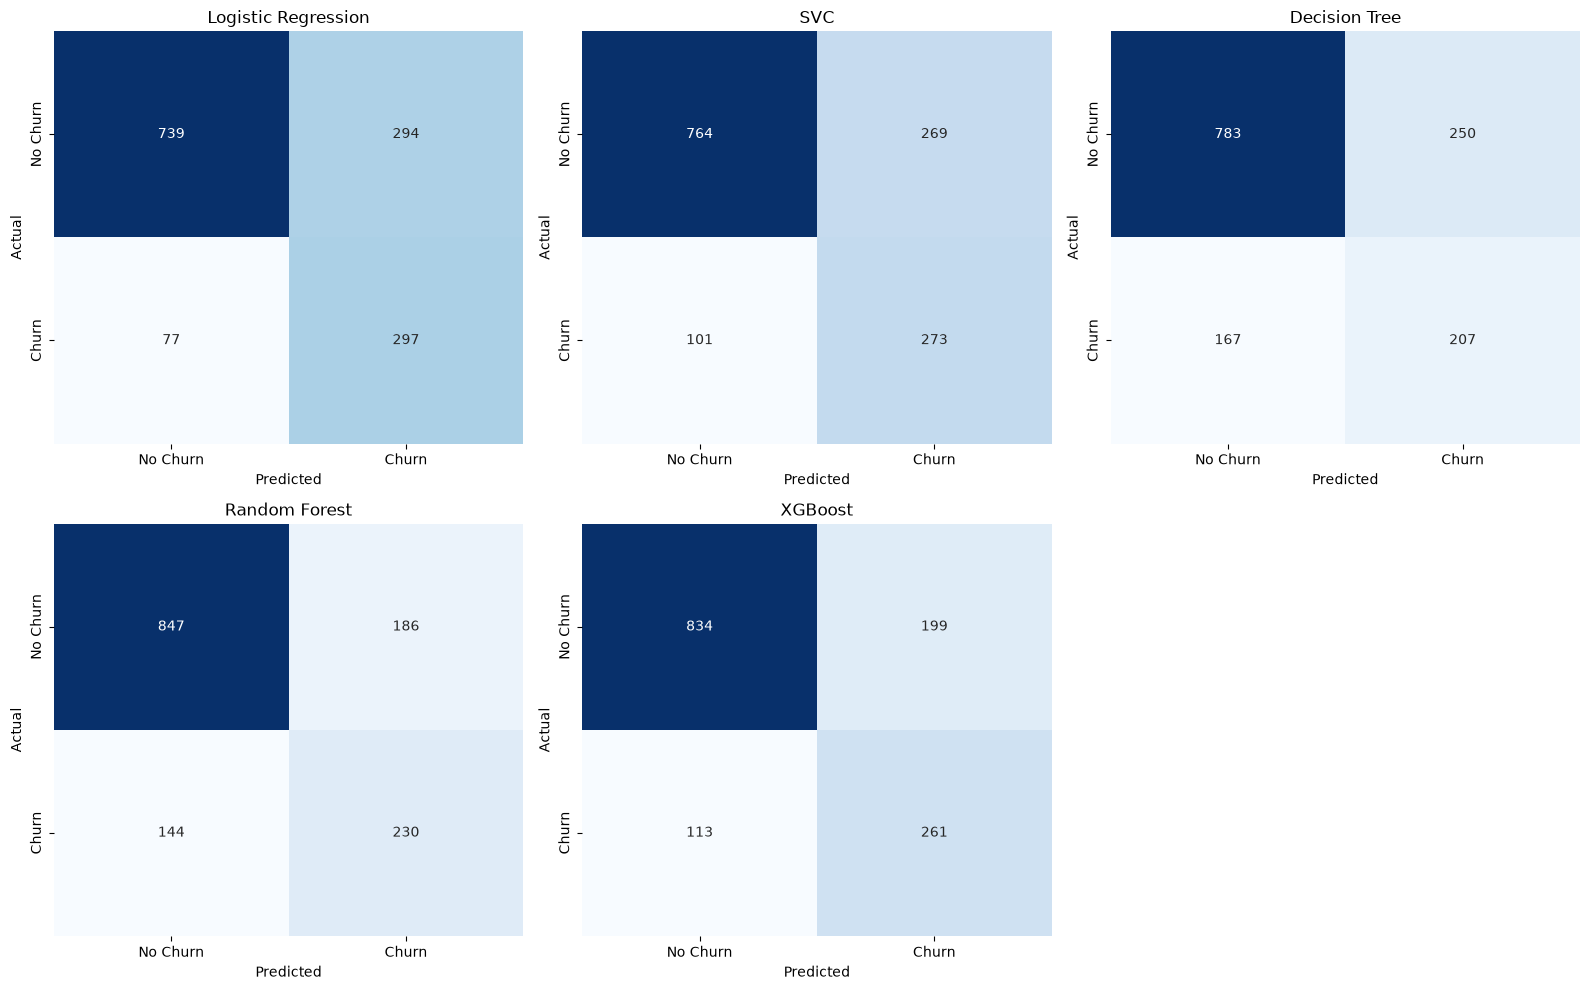

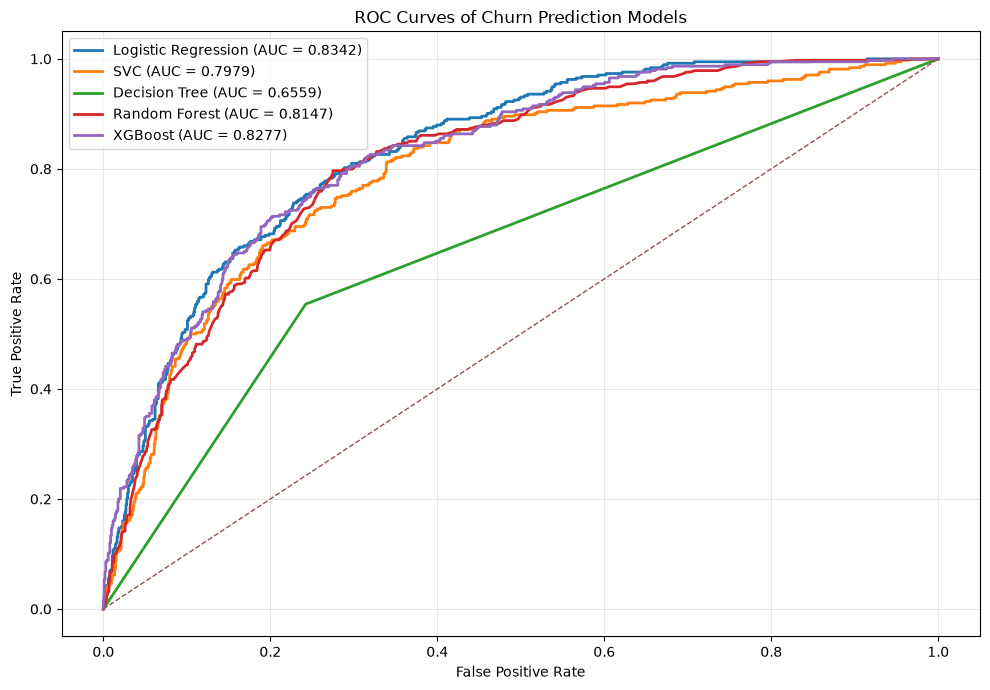

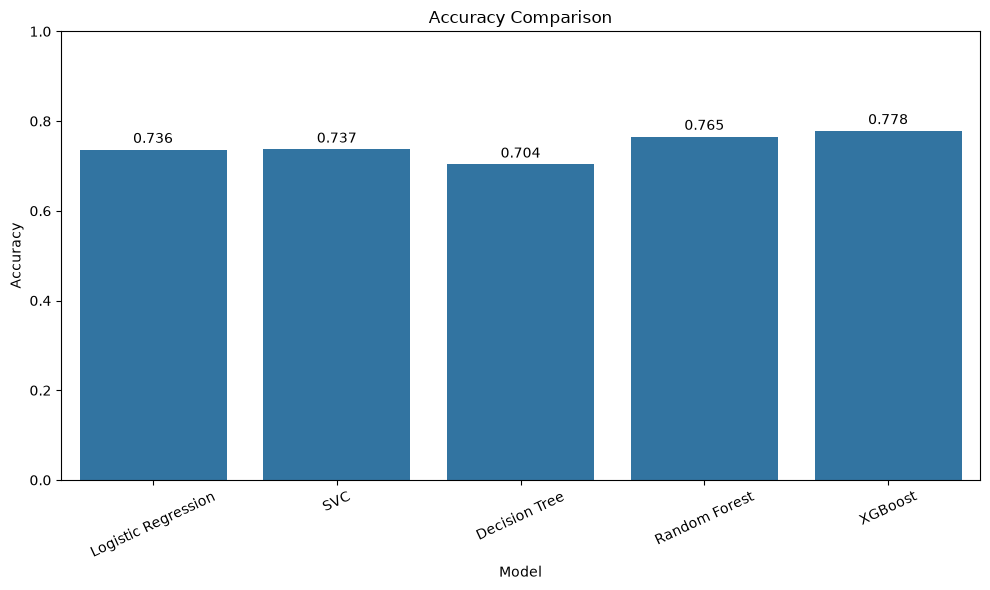

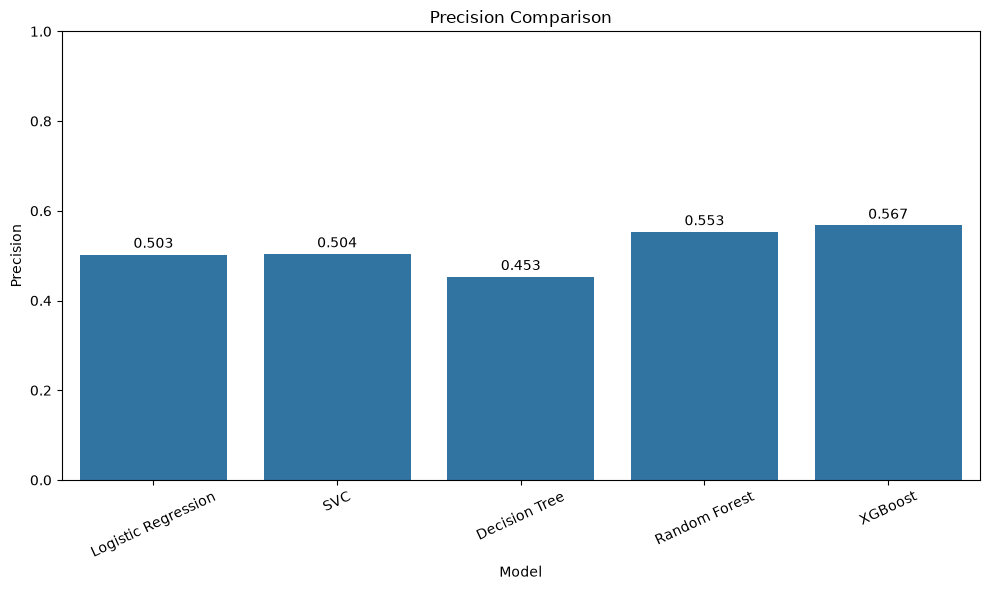

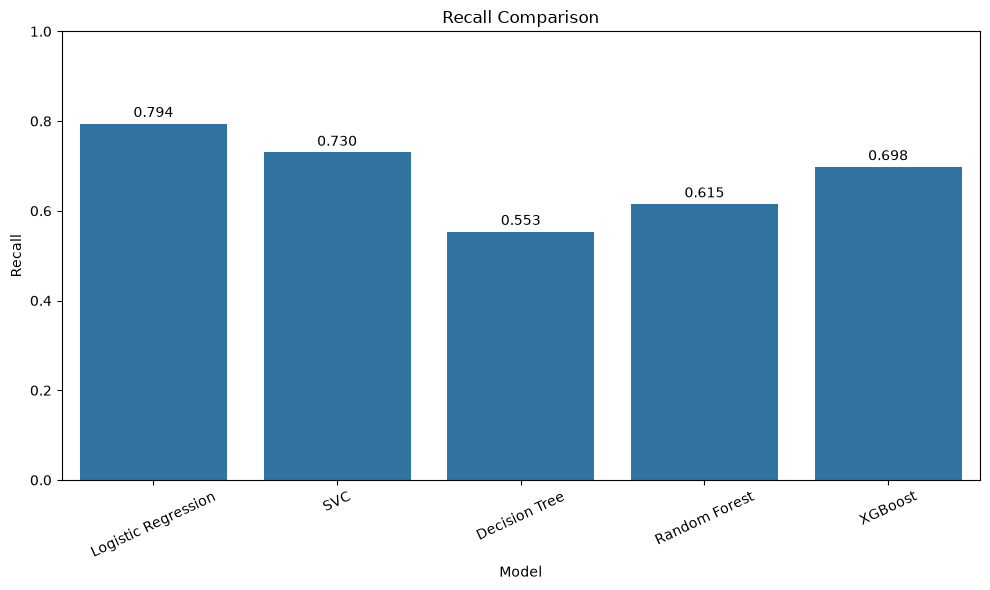

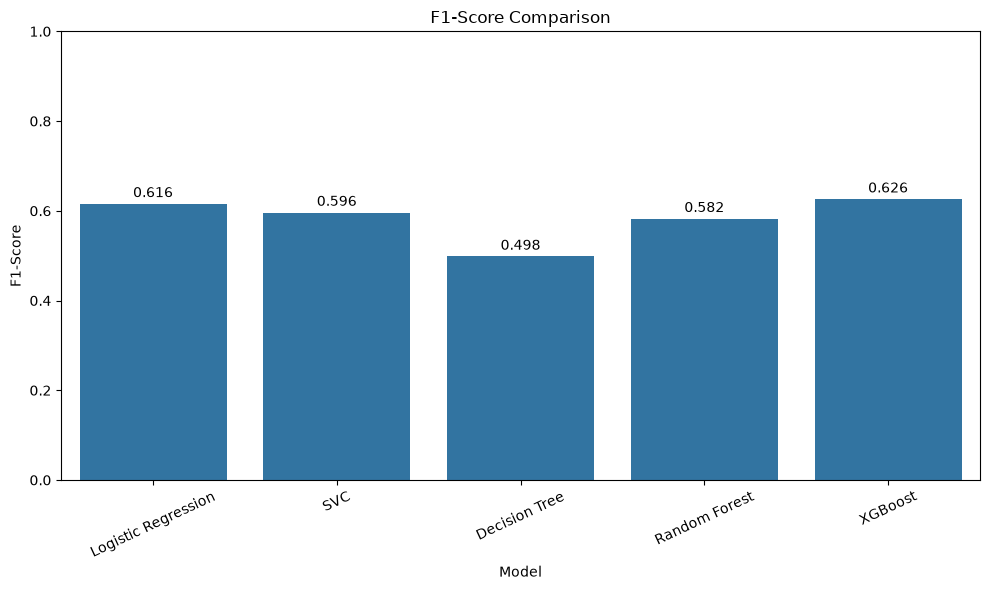

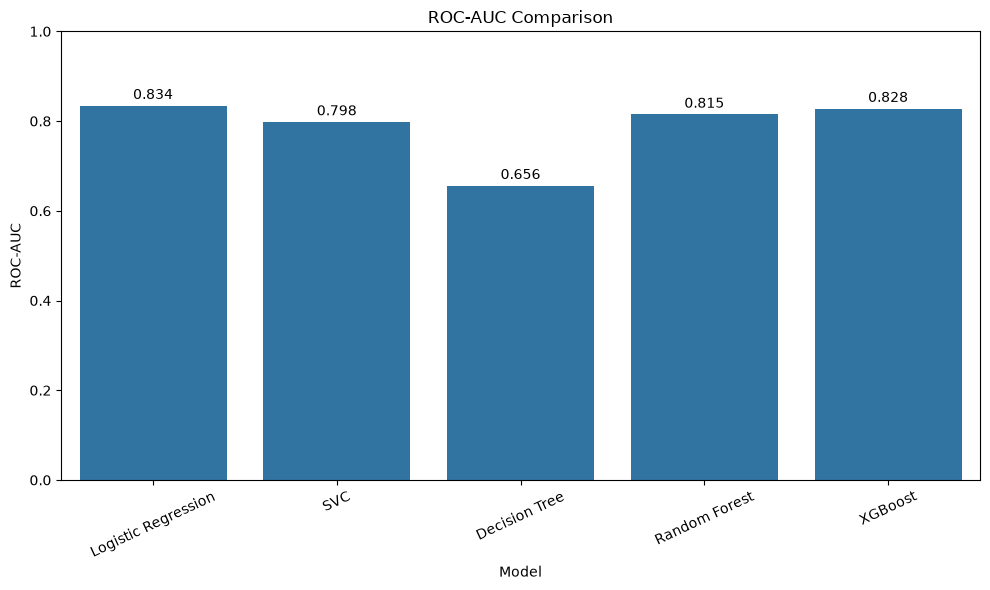

<Figure size 1400x700 with 0 Axes>

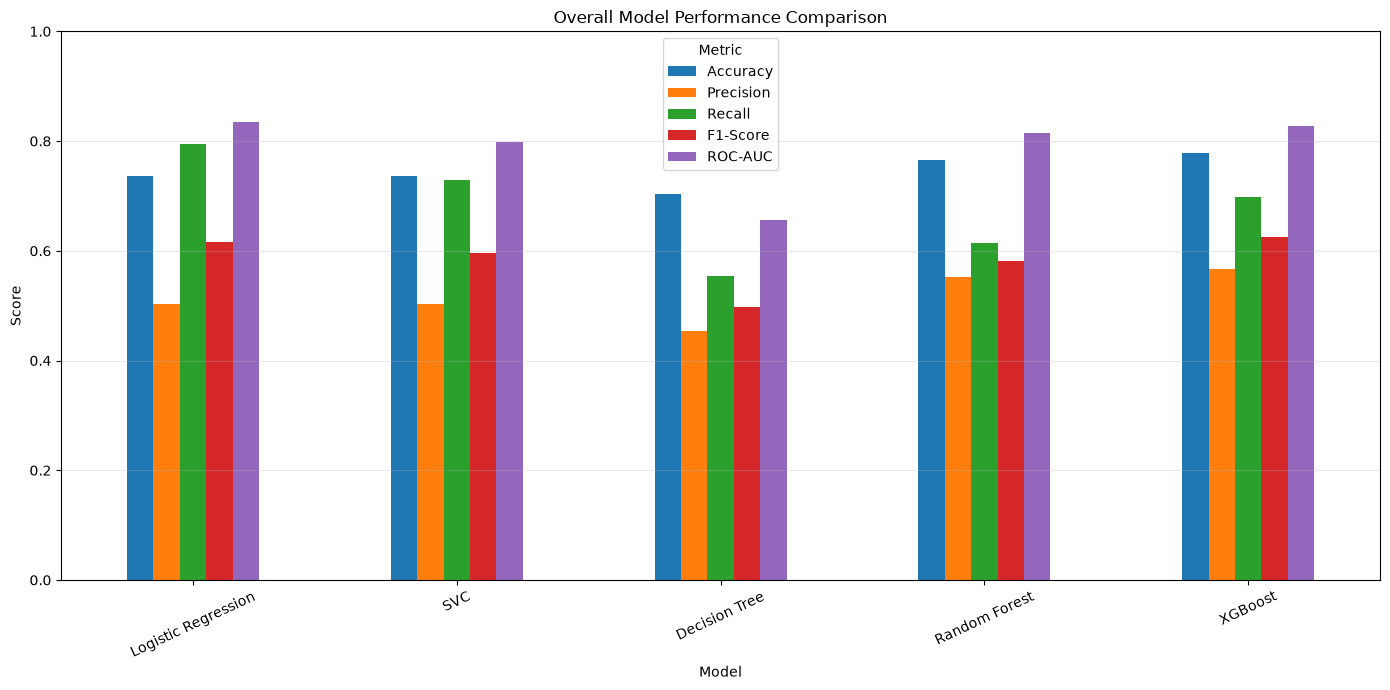

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

X = df_model.drop(columns=['Churn']).copy()
y = df_model['Churn'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print('Original dataset:', X.shape)
print('Training set:', X_train.shape)
print('Testing set:', X_test.shape)

print('\nBefore SMOTE:')
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).mul(100).round(2))

imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns,
    index=X_test_imp.index
)

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print('\nAfter SMOTE:')
print(y_train_smote.value_counts())
print(y_train_smote.value_counts(normalize=True).mul(100).round(2))

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    'SVC': SVC(
        probability=True,
        random_state=42
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

results = []
predictions = {}
probabilities = {}
confusion_matrices = {}
classification_reports = {}

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

    predictions[name] = y_pred
    probabilities[name] = y_prob
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)

    classification_reports[name] = classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn'],
        digits=4,
        zero_division=0
    )

results_df = pd.DataFrame(results)

print('\nModel Comparison:')
display(
    results_df.style.format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1-Score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
)

for name in models:

    print('\n' + '=' * 70)
    print(name)
    print('=' * 70)
    print(classification_reports[name])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, (name, cm) in enumerate(confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axes[i],
        xticklabels=['No Churn', 'Churn'],
        yticklabels=['No Churn', 'Churn']
    )

    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig(
    'confusion_matrices_all_models.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

plt.figure(figsize=(10, 7))

for name in models:

    y_prob = probabilities[name]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC = {auc:.4f})'
    )

plt.plot([0, 1], [0, 1], '--', linewidth=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of Churn Prediction Models')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    'roc_curves_all_models.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for metric in metrics:

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=results_df,
        x='Model',
        y=metric
    )

    plt.ylim(0, 1)
    plt.title(f'{metric} Comparison')
    plt.xticks(rotation=25)
    plt.ylabel(metric)
    plt.xlabel('Model')

    for i, value in enumerate(results_df[metric]):
        plt.text(
            i,
            value + 0.015,
            f'{value:.3f}',
            ha='center',
            fontsize=10
        )

    plt.tight_layout()

    plt.savefig(
        f'{metric.lower().replace("-", "_")}_comparison.png',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

plt.figure(figsize=(14, 7))

results_plot = results_df.set_index('Model')[metrics]

results_plot.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Model')
plt.title('Overall Model Performance Comparison')
plt.xticks(rotation=25)
plt.legend(title='Metric')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'overall_model_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

results_df.to_csv(
    'churn_model_comparison.csv',
    index=False
)